In [1]:
from tqdm import tqdm
import numpy as np
from lmfit import minimize, Parameters, fit_report, Model
import pickle
import os
from pyne2001 import get_dm_full
import json
import corner
import sys

from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, Planck15
import astropy.units as u

from scipy.signal import savgol_filter, resample, correlate
from scipy.fft import fft2, fftshift

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import ScalarFormatter

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['cmr10']
rcParams['font.size'] = 25
rcParams['axes.formatter.use_mathtext'] = True
rcParams['axes.unicode_minus'] = False
rcParams['mathtext.fontset'] = 'cm'
rcParams['text.usetex'] = False

sys.path.insert(0,'/media/ubuntu/ssd/jfaber/dsa110-scat/utils')

#import scinttools as sct
#import burstfittools as bft

/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: v0.0.0-44-gc4edec3-dirty is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: v1.4.0-7-g6469766 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.2.1-6-g1a8a603-dirty is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.2.1-6-g1a8a603 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resour

In [11]:
# -*- coding: utf-8 -*-
"""
Refactored scintillation analysis tools based on scinttools_new.py.

This module provides functions to calculate Auto-Correlation Functions (ACFs)
from spectra, fit Lorentzian models to measure scintillation bandwidth
and modulation index vs frequency, analyze modulation index vs time,
and generate diagnostic plots.
"""

import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from tqdm.auto import tqdm
import warnings
import math # For calculating plot grid size

# --- Configuration ---
# Scintillation bandwidth definition: FWHM of the Lorentzian fit to the ACF.
# The 'gamma' parameter in the Lorentzian model corresponds to HWHM.
# We will fit for HWHM (gamma) and report FWHM = 2 * gamma.
# The 'amplitude' parameter (A) in the fit corresponds to m^2.
# We fit for m = sqrt(A) and report m.

# --- Lorentzian Model Definitions ---

def lorentzian_model(x, amplitude, center, gamma):
    """Standard Lorentzian function, parameterized for lmfit."""
    # gamma is HWHM (Half-Width at Half-Maximum)
    # amplitude is the peak height (related to m^2)
    return amplitude / (1.0 + ((x - center) / gamma)**2)

def lorentzian_model_with_offset(x, amplitude, center, gamma, offset):
    """Lorentzian function with a constant vertical offset."""
    return lorentzian_model(x, amplitude, center, gamma) + offset

def double_lorentzian_model_with_offset(x, amp1, cen1, gam1, amp2, cen2, gam2, offset):
    """Double Lorentzian function with a constant vertical offset."""
    return (lorentzian_model(x, amp1, cen1, gam1) +
            lorentzian_model(x, amp2, cen2, gam2) +
            offset)

# --- Core ACF and Fitting Functions (Frequency Domain) ---

def calculate_acf(spectrum, mask=None, max_lag_bins=None, mean_subtract=True,
                  normalize=True, offspec_mean=0.0):
    """
    Calculates the Auto-Correlation Function (ACF) of a 1D spectrum.

    Args:
        spectrum (np.ndarray): 1D array containing the spectrum data.
        mask (np.ndarray, optional): Boolean mask for the spectrum (True means masked).
                                     Defaults to None (no mask).
        max_lag_bins (int, optional): Maximum lag (in frequency bins) to compute.
                                     Defaults to None (compute for all lags).
        mean_subtract (bool, optional): Subtract the mean before calculating ACF.
                                        Defaults to True.
        normalize (bool, optional): Normalize ACF such that ACF(0) ~ m^2 = Var(I)/<I>^2.
                                    Defaults to True.
        offspec_mean (float, optional): Mean of off-burst spectrum, used in normalization
                                         if provided. Defaults to 0.0.

    Returns:
        tuple: (lags_bins, acf)
            - lags_bins (np.ndarray): Lags in units of frequency bins (0, 1, 2,...).
            - acf (np.ndarray): Calculated auto-correlation function. Returns None if
              calculation fails (e.g., insufficient unmasked data).
    """
    if not isinstance(spectrum, np.ma.MaskedArray):
        spec_ma = np.ma.masked_array(spectrum, mask=mask)
    else:
        # Ensure input mask is combined with internal masking if any
        spec_ma = np.ma.masked_array(spectrum.data, mask=np.logical_or(spectrum.mask, mask if mask is not None else False))

    if spec_ma.count() < 2: # Need at least 2 unmasked points
        warnings.warn("Insufficient unmasked data points to calculate ACF.")
        return np.array([]), None # Return empty array for lags, None for acf

    # Use only unmasked data for calculations
    valid_spec = spec_ma.compressed()
    if valid_spec.size < 2:
        warnings.warn("Insufficient unmasked data points after compression.")
        return np.array([]), None

    mean_spec = np.mean(valid_spec)

    if mean_subtract:
        # Create working array, subtract mean only from unmasked elements
        work_spec = spec_ma.astype(float, copy=True) # Work with floats
        work_spec[~spec_ma.mask] -= mean_spec
        # Ensure masked values are 0 for correlation calculation
        work_spec.fill_value = 0.0
        data_for_corr = work_spec.filled()
    else:
        work_spec = spec_ma.astype(float, copy=True)
        work_spec.fill_value = 0.0
        data_for_corr = work_spec.filled()


    n_chan = len(spectrum)
    if max_lag_bins is None:
        max_lag_bins = n_chan -1
    else:
        max_lag_bins = min(max_lag_bins, n_chan - 1)

    # Use numpy.correlate for efficiency
    # 'valid' mode computes correlation only where signals fully overlap
    # Need 'full' mode and then select lags, or implement manually for mask handling
    # Manual implementation for precise mask handling and normalization:

    lags_bins = np.arange(max_lag_bins + 1)
    acf = np.zeros(max_lag_bins + 1, dtype=float)
    counts = np.zeros(max_lag_bins + 1, dtype=int)

    # Pre-calculate which elements are valid (not masked)
    valid_indices = ~spec_ma.mask

    for lag in lags_bins: # No need for tqdm usually, it's fast
        if lag == 0:
            valid_pair_indices = valid_indices
            if np.sum(valid_pair_indices) > 0:
                acf[lag] = np.sum(work_spec[valid_pair_indices]**2)
                counts[lag] = np.sum(valid_pair_indices)
            else:
                acf[lag] = np.nan # Avoid division by zero later if count is 0
                counts[lag] = 0
            continue

        # Indices for lag > 0
        idx1 = np.arange(n_chan - lag)
        idx2 = np.arange(lag, n_chan)

        # Check mask for both elements in the pair
        valid_pair_indices = valid_indices[idx1] & valid_indices[idx2]

        if np.sum(valid_pair_indices) > 0:
            acf[lag] = np.sum(work_spec[idx1[valid_pair_indices]] * work_spec[idx2[valid_pair_indices]])
            counts[lag] = np.sum(valid_pair_indices)
        else:
            acf[lag] = np.nan # Avoid division by zero if count is 0
            counts[lag] = 0


    # --- Normalization ---
    # Avoid division by zero where counts are zero
    valid_counts = counts > 0
    if np.any(valid_counts): # Proceed only if there's something to normalize
        acf[valid_counts] /= counts[valid_counts]
    else: # If all counts are zero, acf calculation failed earlier or data is fully masked
         return lags_bins, None

    if normalize:
        # Normalize by variance proxy: <I>^2 or (<I> - <I_off>)^2
        # This makes ACF(0) approx Var(I)/<I>^2 = m^2
        effective_mean = mean_spec - offspec_mean
        if effective_mean != 0:
            # Check variance: acf[0] should be Var(I) if mean_subtract=True
            variance_est = acf[0] if mean_subtract else np.var(valid_spec)
            norm_factor = effective_mean**2
            if norm_factor > 1e-15: # Avoid division by zero or tiny numbers
                 acf /= norm_factor
            else:
                warnings.warn(f"Normalization factor (effective_mean^2 = {norm_factor:.2e}) is close to zero. Skipping ACF normalization by power.")
                # Fallback: normalize by variance estimate if possible
                if variance_est > 1e-15:
                    acf /= variance_est # Makes ACF(0) approx 1
                    warnings.warn("Normalizing ACF by variance estimate instead.")
                else:
                    warnings.warn("Variance estimate also near zero. ACF remains unnormalized by power.")
                    acf = np.full_like(acf, np.nan) # Cannot reliably normalize
        else:
            warnings.warn("Effective mean is zero. Cannot normalize ACF by power.")
            # Normalize by variance? Or return unnormalized?
            # Let's normalize by variance if possible, making ACF(0) approx 1
            variance_est = acf[0] if mean_subtract else np.var(valid_spec)
            if variance_est > 1e-15:
                acf /= variance_est
                warnings.warn("Normalizing ACF by variance estimate instead.")
            else:
                warnings.warn("Variance estimate also near zero. ACF remains unnormalized.")
                acf = np.full_like(acf, np.nan) # Cannot reliably normalize


    if np.all(np.isnan(acf)):
        return lags_bins, None

    return lags_bins, acf


def fit_acf_model(lags_bins, acf, freq_res_mhz, model_type='single',
                  fit_lag_range_mhz=None, initial_gamma_mhz=0.1):
    """
    Fits a Lorentzian model to the ACF.

    Args:
        lags_bins (np.ndarray): Lags in units of frequency bins (0, 1, 2,...).
        acf (np.ndarray): Auto-correlation function values.
        freq_res_mhz (float): Frequency resolution in MHz per bin.
        model_type (str, optional): Type of model ('single', 'double').
                                    Defaults to 'single'.
        fit_lag_range_mhz (float, optional): Fit only lags up to this value [MHz].
                                             Defaults to None (fit all lags).
        initial_gamma_mhz (float, optional): Initial guess for HWHM gamma [MHz].
                                              Defaults to 0.1 MHz.

    Returns:
        lmfit.model.ModelResult or None: The fit result object, or None if fit fails.
    """
    if acf is None or len(acf) < 2 or np.all(np.isnan(acf)):
        warnings.warn("ACF is None or too short or all NaN, cannot fit.")
        return None

    lags_mhz = lags_bins * freq_res_mhz

    # Select data range for fitting
    if fit_lag_range_mhz is not None:
        fit_indices = np.where(lags_mhz <= fit_lag_range_mhz)[0]
        if len(fit_indices) < 3: # Need points for fit
            warnings.warn(f"Less than 3 data points within fit range {fit_lag_range_mhz} MHz. Cannot fit.")
            return None
        fit_lags_mhz = lags_mhz[fit_indices]
        fit_acf = acf[fit_indices]
    else:
        fit_lags_mhz = lags_mhz
        fit_acf = acf

    # Remove NaNs from fitting data
    nan_mask = np.isnan(fit_acf)
    if np.all(nan_mask):
        warnings.warn("All ACF values in the fitting range are NaN. Cannot fit.")
        return None
    fit_lags_mhz = fit_lags_mhz[~nan_mask]
    fit_acf = fit_acf[~nan_mask]

    if len(fit_acf) < 3: # Check again after NaN removal
        warnings.warn(f"Less than 3 valid data points remaining for fit. Cannot fit.")
        return None


    # --- Set up lmfit model ---
    if model_type == 'single':
        model = Model(lorentzian_model_with_offset)
        params = model.make_params()
        # Initial guesses and bounds
        initial_amplitude = fit_acf[0] if fit_acf[0] > 0 else 1e-3 # Should be m^2
        params['amplitude'].set(value=initial_amplitude, min=1e-9) # m^2 > 0
        params['center'].set(value=0.0, vary=False) # Assume peak at zero lag
        params['gamma'].set(value=initial_gamma_mhz, min=1e-6) # HWHM > 0 [MHz]
        # Improved offset guess: median of last half, bounded reasonably
        offset_guess = np.nanmedian(fit_acf[len(fit_acf)//2:])
        params['offset'].set(value=offset_guess if not np.isnan(offset_guess) else 0.0, min=-1.0, max=1.0)


    elif model_type == 'double':
        model = Model(double_lorentzian_model_with_offset)
        params = model.make_params()
        initial_amplitude = fit_acf[0] if fit_acf[0] > 0 else 1e-3
        # Guesses might need refinement based on data
        params['amp1'].set(value=initial_amplitude * 0.7, min=1e-9)
        params['cen1'].set(value=0.0, vary=False)
        params['gam1'].set(value=initial_gamma_mhz, min=1e-6)
        params['amp2'].set(value=initial_amplitude * 0.3, min=1e-9)
        params['cen2'].set(value=0.0, vary=False)
        params['gam2'].set(value=initial_gamma_mhz * 5, min=1e-6) # Guess broader component
        offset_guess = np.nanmedian(fit_acf[len(fit_acf)//2:])
        params['offset'].set(value=offset_guess if not np.isnan(offset_guess) else 0.0, min=-1.0, max = 1.0)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # Perform the fit
    try:
        # Add weights? Penalize points far from zero lag? Use ACF variance? For now, no weights.
        fit_result = model.fit(fit_acf, params, x=fit_lags_mhz, nan_policy='omit')
        if not fit_result.success:
            warnings.warn(f"lmfit optimization failed: {fit_result.message}")
            # Optionally return the failed fit result for inspection
            # return fit_result
            return None
        return fit_result
    except Exception as e:
        warnings.warn(f"lmfit fitting process raised an exception: {e}")
        return None


def extract_scint_params(fit_result):
    """
    Extracts key scintillation parameters from an lmfit ModelResult.

    Args:
        fit_result (lmfit.model.ModelResult): Successful result from fit_acf_model.

    Returns:
        dict: Dictionary containing parameters like 'fwhm_mhz', 'fwhm_mhz_err',
              'mod_index', 'mod_index_err', 'offset', 'offset_err', and potentially
              parameters for a second component if model was 'double'. Returns None
              if input is None or extraction fails.
    """
    if fit_result is None:
        return None

    params = fit_result.params
    extracted = {}

    try:
        # Component 1
        amp1 = params['amplitude'].value if 'amplitude' in params else params['amp1'].value
        gam1 = params['gamma'].value if 'gamma' in params else params['gam1'].value
        amp1_err = params['amplitude'].stderr if 'amplitude' in params else params['amp1'].stderr
        gam1_err = params['gamma'].stderr if 'gamma' in params else params['gam1'].stderr

        # FWHM = 2 * HWHM (gamma)
        extracted['fwhm_mhz'] = 2.0 * gam1
        extracted['fwhm_mhz_err'] = 2.0 * gam1_err if gam1_err is not None else np.nan # Use NaN for missing errors

        # Mod index m = sqrt(Amplitude)
        extracted['mod_index'] = np.sqrt(amp1) if amp1 > 0 else 0.0
        # Error propagation: err(sqrt(A)) = err(A) / (2*sqrt(A))
        if amp1 > 1e-9 and amp1_err is not None:
            # Check if mod_index is also non-zero before division
            if extracted['mod_index'] > 1e-9 :
                extracted['mod_index_err'] = abs(amp1_err / (2.0 * extracted['mod_index']))
            else:
                extracted['mod_index_err'] = np.nan
        else:
             extracted['mod_index_err'] = np.nan


        # Offset
        extracted['offset'] = params['offset'].value
        extracted['offset_err'] = params['offset'].stderr if params['offset'].stderr is not None else np.nan

        # Component 2 (if double fit)
        if 'amp2' in params:
            amp2 = params['amp2'].value
            gam2 = params['gam2'].value
            amp2_err = params['amp2'].stderr
            gam2_err = params['gam2'].stderr

            extracted['fwhm_mhz_2'] = 2.0 * gam2
            extracted['fwhm_mhz_err_2'] = 2.0 * gam2_err if gam2_err is not None else np.nan

            extracted['mod_index_2'] = np.sqrt(amp2) if amp2 > 0 else 0.0
            if amp2 > 1e-9 and amp2_err is not None:
                if extracted['mod_index_2'] > 1e-9:
                    extracted['mod_index_err_2'] = abs(amp2_err / (2.0 * extracted['mod_index_2']))
                else:
                    extracted['mod_index_err_2'] = np.nan
            else:
                extracted['mod_index_err_2'] = np.nan

    except KeyError as e:
        warnings.warn(f"Parameter extraction failed: Missing key {e} in fit result.")
        return None
    except TypeError as e:
        # Handles cases where stderr might be None or other type issues
        warnings.warn(f"Parameter extraction failed due to type error: {e}. Returning partial results.")
        # Return partially filled dict, errors already default to NaN or handled

    # Final check for NaNs in essential parameters
    if np.isnan(extracted.get('fwhm_mhz', np.nan)) or np.isnan(extracted.get('mod_index', np.nan)):
        warnings.warn("Essential parameters (FWHM or ModIndex) could not be extracted or are NaN.")
        # Decide whether to return partial or None based on needs
        # return None # Stricter: fail if key params missing
        pass # Lenient: return what could be extracted


    return extracted

# --- Workflow Functions (Frequency Domain) ---

def analyze_spectrum(spectrum, freqs_mhz, mask=None, max_lag_mhz=10.0,
                     model_type='single', fit_lag_range_mhz=None,
                     offspec_mean=0.0, initial_gamma_mhz=0.1):
    """
    Performs full ACF analysis (calculation, fitting, parameter extraction)
    on a single 1D spectrum.

    Args:
        spectrum (np.ndarray): 1D array containing the spectrum data.
        freqs_mhz (np.ndarray): Corresponding frequencies in MHz.
        mask (np.ndarray, optional): Boolean mask for the spectrum (True means masked).
        max_lag_mhz (float, optional): Max lag for ACF calculation [MHz]. Defaults to 10.0.
        model_type (str, optional): 'single' or 'double' Lorentzian fit. Defaults to 'single'.
        fit_lag_range_mhz (float, optional): Max lag for fitting range [MHz]. Defaults to None (use max_lag_mhz).
        offspec_mean (float, optional): Mean of off-burst spectrum for normalization. Defaults to 0.0.
        initial_gamma_mhz (float, optional): Initial guess for HWHM gamma [MHz]. Defaults to 0.1.


    Returns:
        dict: A dictionary containing results:
            'lags_mhz': Lags in MHz (symmetric: -max to +max).
            'acf': ACF values (symmetric).
            'fit_result': The lmfit ModelResult object (or None).
            'params': Dictionary of extracted parameters (or None).
            'freq_res_mhz': Frequency resolution.
            'status': 'OK' or 'Error: specific message'.
    """
    results = {'status': 'OK'}
    if len(freqs_mhz) < 2:
        results['status'] = 'Error: Need at least 2 frequency channels.'
        return results

    # Determine frequency resolution (handle potential non-uniformity)
    freq_diffs = np.diff(freqs_mhz)
    if len(freq_diffs)==0: # Handle case of only 2 channels
        freq_res_mhz = np.abs(freqs_mhz[1] - freqs_mhz[0])
    elif np.allclose(freq_diffs, freq_diffs[0]):
        freq_res_mhz = np.abs(freq_diffs[0])
    else:
        # Use average resolution if not uniform, with a warning
        freq_res_mhz = np.abs(np.mean(freq_diffs))
        warnings.warn("Frequency channels are not uniformly spaced. Using average resolution.")
    results['freq_res_mhz'] = freq_res_mhz

    if freq_res_mhz <= 0:
        results['status'] = 'Error: Invalid frequency resolution <= 0.'
        return results


    # Calculate ACF
    max_lag_bins = int(np.ceil(max_lag_mhz / freq_res_mhz))
    lags_bins, acf_raw = calculate_acf(spectrum, mask=mask, max_lag_bins=max_lag_bins,
                                    mean_subtract=True, normalize=True,
                                    offspec_mean=offspec_mean)

    if acf_raw is None:
        results['status'] = 'Error: ACF calculation failed.'
        # Provide empty placeholders for consistent output structure
        results['lags_mhz'] = np.array([])
        results['acf'] = np.array([])
        results['fit_result'] = None
        results['params'] = None
        return results

    # Make symmetric for output/plotting convenience (fitting uses positive lags)
    lags_mhz_sym = np.concatenate((-lags_bins[1:][::-1] * freq_res_mhz, lags_bins * freq_res_mhz))
    acf_sym = np.concatenate((acf_raw[1:][::-1], acf_raw))
    results['lags_mhz'] = lags_mhz_sym
    results['acf'] = acf_sym

    # Fit ACF Model
    fit_range = fit_lag_range_mhz if fit_lag_range_mhz is not None else max_lag_mhz
    # Pass freq_res_mhz to fit_acf_model if needed for initial guesses based on bins
    fit_result = fit_acf_model(lags_bins, acf_raw, freq_res_mhz,
                               model_type=model_type,
                               fit_lag_range_mhz=fit_range,
                               initial_gamma_mhz=initial_gamma_mhz)
    # Store freq_res in userkws for potential later use in plotting/analysis
    if fit_result is not None:
        fit_result.userkws['freq_res_mhz'] = freq_res_mhz


    results['fit_result'] = fit_result

    # Extract Parameters
    scint_params = extract_scint_params(fit_result)
    results['params'] = scint_params

    if fit_result is None or scint_params is None:
        current_status = results.get('status', 'OK')
        if current_status == 'OK': # Don't overwrite ACF calc error
            results['status'] = 'Warning: ACF fitting or parameter extraction failed.'
        # Keep going, but params/fit_result might be None


    return results


def analyze_subbands(spectrum, freqs_mhz, num_subbands=8, mask=None,
                     divide_method='equal_freq', **kwargs):
    """
    Divides a spectrum into sub-bands and analyzes each using analyze_spectrum.

    Args:
        spectrum (np.ndarray): 1D array containing the full spectrum data.
        freqs_mhz (np.ndarray): Corresponding frequencies in MHz.
        num_subbands (int, optional): Number of sub-bands to divide into. Defaults to 8.
        mask (np.ndarray, optional): Boolean mask for the spectrum (True means masked).
        divide_method (str, optional): How to divide: 'equal_freq' (equal frequency range)
                                      or 'equal_snr' (approx. equal integrated intensity).
                                      Defaults to 'equal_freq'.
        **kwargs: Additional keyword arguments passed directly to analyze_spectrum
                  (e.g., max_lag_mhz, model_type, offspec_mean, etc.).

    Returns:
        list[dict]: A list of result dictionaries, one for each sub-band.
                    Each dictionary contains:
                    'subband_index': 0-based index.
                    'freq_center_mhz': Central frequency of the sub-band.
                    'freq_range_mhz': (min_freq, max_freq) of the sub-band.
                    'analysis_results': The dictionary returned by analyze_spectrum.
    """
    if not isinstance(spectrum, np.ma.MaskedArray):
        spec_ma = np.ma.masked_array(spectrum, mask=mask)
    else:
        spec_ma = np.ma.masked_array(spectrum.data, mask=np.logical_or(spectrum.mask, mask if mask is not None else False))


    n_chan = len(spec_ma)
    all_indices = np.arange(n_chan)
    subband_results = []

    if n_chan < num_subbands * 2 : # Ensure at least 2 channels per subband on average
        warnings.warn(f"Number of channels ({n_chan}) is low for {num_subbands} subbands. Reducing num_subbands.")
        num_subbands = max(1, n_chan // 2)
        if num_subbands == 0: # Handle edge case of very few channels
            warnings.warn(f"Fewer than 2 channels available. Cannot perform subband analysis.")
            return subband_results


    if divide_method == 'equal_freq':
        # Ensure splits result in at least 1 channel per subband, preferably more
        indices_per_subband = np.array_split(all_indices, num_subbands)
        # Get start index of subbands > 0; handle case where array_split might return empty arrays if num_subbands > n_chan
        split_indices = [indices[0] for indices in indices_per_subband[1:] if len(indices) > 0]


    elif divide_method == 'equal_snr':
        # Calculate cumulative intensity (use fill_value=0 for masked points)
        valid_spec = spec_ma.compressed()
        if len(valid_spec) == 0:
            warnings.warn("Cannot use equal_snr division: No unmasked data. Falling back to 'equal_freq'.")
            indices_per_subband = np.array_split(all_indices, num_subbands)
            split_indices = [indices[0] for indices in indices_per_subband[1:] if len(indices) > 0]
        else:
            mean_signal = np.mean(valid_spec) # Use mean of valid points
            # Get offspec mean if provided, otherwise assume 0 baseline
            offspec_mean_val = 0.0
            if 'offspec_spectrum' in kwargs and kwargs['offspec_spectrum'] is not None:
                # Ensure offspec_spectrum is a masked array for calculation
                offspec_ma = np.ma.masked_array(kwargs['offspec_spectrum'])
                offspec_mean_val = np.ma.mean(offspec_ma) if offspec_ma.count() > 0 else 0.0
            elif 'offspec_mean' in kwargs:
                offspec_mean_val = kwargs['offspec_mean']

            signal_est = np.maximum(0, spec_ma.filled(0.0) - offspec_mean_val) # Approx signal above baseline
            cumul_signal = np.cumsum(signal_est)
            total_signal = cumul_signal[-1] if len(cumul_signal) > 0 else 0.0

            if total_signal <=0:
                warnings.warn("Total estimated signal is non-positive. Cannot use 'equal_snr'. Falling back to 'equal_freq'.")
                indices_per_subband = np.array_split(all_indices, num_subbands)
                split_indices = [indices[0] for indices in indices_per_subband[1:] if len(indices) > 0]
            else:
                target_signal_per_subband = total_signal / num_subbands
                split_indices = []
                current_target = target_signal_per_subband
                last_idx = 0
                # Find indices where cumulative signal crosses target boundaries
                for i in range(num_subbands - 1):
                    # searchsorted finds insertion point; ensures index > last_idx
                    found_idx = np.searchsorted(cumul_signal, current_target, side='left')
                    # Ensure index advances and doesn't leave too few points at the end
                    found_idx = max(found_idx, last_idx + 1)
                    # Ensure enough channels left for remaining subbands (at least 1 each)
                    found_idx = min(found_idx, n_chan - (num_subbands - 1 - i))
                    split_indices.append(found_idx)
                    last_idx = found_idx
                    current_target += target_signal_per_subband
    else:
        raise ValueError(f"Unknown divide_method: {divide_method}")

    # Split the indices using the calculated split points
    subband_indices = np.split(all_indices, split_indices)

    # --- Analyze each sub-band ---
    for i, indices in enumerate(subband_indices):
        if len(indices) < 2:
            warnings.warn(f"Sub-band {i} has less than 2 channels, skipping analysis.")
            continue

        sub_spec = spec_ma[indices]
        sub_freqs = freqs_mhz[indices]
        sub_mask = spec_ma.mask[indices] if np.ma.is_masked(spec_ma) else None

        # Calculate offspec_mean specific to this sub-band if offspec_spectrum provided
        current_kwargs = kwargs.copy()
        if 'offspec_spectrum' in current_kwargs:
            offspec_full = current_kwargs.pop('offspec_spectrum') # Remove from kwargs passed down
            if offspec_full is not None and len(offspec_full) == n_chan:
                # Assume offspec_full is 1D array or masked array
                sub_offspec_data = offspec_full[indices]
                if isinstance(sub_offspec_data, np.ma.MaskedArray):
                    # Calculate mean only if there are unmasked points
                    current_kwargs['offspec_mean'] = np.ma.mean(sub_offspec_data) if sub_offspec_data.count() > 0 else 0.0
                else: # Assume simple numpy array
                    # Ensure it's not empty before taking mean
                    current_kwargs['offspec_mean'] = np.mean(sub_offspec_data) if len(sub_offspec_data) > 0 else 0.0
            elif 'offspec_mean' not in current_kwargs:
                # If full offspec not provided or wrong shape, use global if passed, else 0
                current_kwargs['offspec_mean'] = kwargs.get('offspec_mean', 0.0)


        print(f"--- Analyzing Sub-band {i} ({sub_freqs[0]:.1f} - {sub_freqs[-1]:.1f} MHz) ---")
        analysis = analyze_spectrum(sub_spec.data, sub_freqs, mask=sub_mask, **current_kwargs)

        sub_results = {
            'subband_index': i,
            'freq_center_mhz': np.mean(sub_freqs),
            'freq_range_mhz': (sub_freqs[0], sub_freqs[-1]),
            'num_channels': len(indices),
            'analysis_results': analysis
        }
        subband_results.append(sub_results)

    return subband_results

# --- Time Domain Analysis ---

def analyze_modulation_over_time(dynamic_spectrum, times_sec, burst_indices,
                                 time_chunk_size_bins, time_overlap_bins=0,
                                 freqs_mhz=None, freq_range_mhz=None):
    """
    Calculates the modulation index (std/mean) over time chunks.

    Args:
        dynamic_spectrum (np.ma.MaskedArray): 2D dynamic spectrum (freq, time).
        times_sec (np.ndarray): 1D array of time coordinates for each bin [seconds].
        burst_indices (tuple): Start and end bin index of the burst (start_bin, end_bin).
        time_chunk_size_bins (int): Number of time bins per analysis chunk.
        time_overlap_bins (int, optional): Number of overlapping bins between chunks. Defaults to 0.
        freqs_mhz (np.ndarray, optional): 1D array of frequencies. Required if freq_range_mhz is used.
        freq_range_mhz (tuple, optional): (min_freq, max_freq) to average over.
                                          Defaults to None (use all frequencies).

    Returns:
        list[dict]: List of dictionaries, one per time chunk, containing:
            'time_center_sec': Center time of the chunk.
            'time_range_sec': (start_time, end_time) of the chunk.
            'mod_index': Calculated modulation index (std/mean).
            'mean': Mean intensity in the chunk.
            'std_dev': Standard deviation in the chunk.
            'num_points': Number of unmasked data points used.
            'status': 'OK' or 'Error: message'.
    """
    results_list = []
    if not isinstance(dynamic_spectrum, np.ma.MaskedArray):
         dynamic_spectrum = np.ma.masked_array(dynamic_spectrum) # Ensure it's masked

    n_freq, n_time = dynamic_spectrum.shape
    burst_start, burst_end = burst_indices
    # Adjust burst_end to be exclusive, matching Python slicing
    burst_end_exclusive = min(burst_end, n_time)
    burst_duration_bins = burst_end_exclusive - burst_start

    if burst_duration_bins <= 0:
        warnings.warn("Burst duration is non-positive based on indices.")
        return results_list

    if time_chunk_size_bins <= 1:
        warnings.warn("time_chunk_size_bins must be > 1 to calculate standard deviation.")
        return results_list

    # Determine frequency range indices
    if freq_range_mhz is not None:
        if freqs_mhz is None:
             raise ValueError("freqs_mhz must be provided if freq_range_mhz is set.")
        freq_min, freq_max = min(freq_range_mhz), max(freq_range_mhz) # Ensure order
        # Find indices corresponding to the frequency range
        if freqs_mhz[0] > freqs_mhz[-1]: # Frequencies decreasing
            freq_mask = (freqs_mhz <= freq_max) & (freqs_mhz >= freq_min)
        else: # Frequencies increasing
            freq_mask = (freqs_mhz >= freq_min) & (freqs_mhz <= freq_max)
        freq_indices = np.where(freq_mask)[0]

        if len(freq_indices) == 0:
            warnings.warn(f"No frequency channels found in range {freq_range_mhz} MHz.")
            return results_list
    else:
        freq_indices = np.arange(n_freq)

    # Calculate step size for non-overlapping part of chunks
    time_step_bins = time_chunk_size_bins - time_overlap_bins
    if time_step_bins <= 0:
        warnings.warn("time_overlap_bins >= time_chunk_size_bins, results in zero or negative step. Setting overlap to 0.")
        time_step_bins = time_chunk_size_bins
        time_overlap_bins = 0


    # Iterate through time chunks within the burst duration
    # range(start, stop, step) - stop is exclusive
    for t_start in range(burst_start, burst_end_exclusive, time_step_bins):
        t_end = t_start + time_chunk_size_bins
        # Ensure chunk doesn't exceed burst end
        t_end = min(t_end, burst_end_exclusive)
        actual_chunk_size = t_end - t_start

        if actual_chunk_size < 2 : continue # Need at least 2 points for std dev

        time_slice_indices = np.arange(t_start, t_end)

        # Extract the 2D data chunk (freq x time) using advanced indexing
        data_chunk_2d = dynamic_spectrum[freq_indices[:, np.newaxis], time_slice_indices]

        # Average over frequency first to get a 1D time series for the chunk
        # Only include time bins where *at least one* frequency channel is unmasked
        # Axis 0 is frequency. Keepdims=True helps with broadcasting later if needed.
        time_series_chunk = np.ma.mean(data_chunk_2d, axis=0)

        # Calculate stats on the 1D time series
        chunk_mean = np.ma.mean(time_series_chunk)
        chunk_std = np.ma.std(time_series_chunk)
        # Count valid points in the *time series* after frequency averaging
        chunk_count = time_series_chunk.count()

        chunk_result = {
            'time_center_sec': np.mean(times_sec[time_slice_indices]),
            'time_range_sec': (times_sec[t_start], times_sec[t_end-1]),
            'mod_index': np.nan,
            'mean': chunk_mean if chunk_mean is not np.ma.masked else np.nan,
            'std_dev': chunk_std if chunk_std is not np.ma.masked else np.nan,
            'num_points': chunk_count,
            'status': 'OK'
        }

        if chunk_count < 2:
            chunk_result['status'] = 'Error: < 2 valid points in time chunk'
        elif np.ma.is_masked(chunk_mean) or np.isnan(chunk_mean) or chunk_mean == 0:
            # Handle mean=0 specifically, m=inf might be valid in noiseless case, but nan is safer
            chunk_result['status'] = 'Error: Mean is zero, masked, or NaN'
            chunk_result['mod_index'] = np.nan
        elif np.ma.is_masked(chunk_std) or np.isnan(chunk_std):
             chunk_result['status'] = 'Error: Std deviation is masked or NaN'
        else:
            # Ensure mean isn't dangerously small before division
            if abs(chunk_mean) < 1e-12:
                chunk_result['status'] = 'Warning: Mean is very close to zero'
                chunk_result['mod_index'] = np.inf # Or NaN? Inf seems more indicative
            else:
                chunk_result['mod_index'] = chunk_std / chunk_mean

        results_list.append(chunk_result)

    return results_list


# --- Plotting Functions ---

def plot_acf_fit(ax, lags_mhz, acf, fit_result, params, title="ACF Fit", fontsize=8):
    """
    Plots ACF and fit on a given matplotlib axes object.

    Args:
        ax (matplotlib.axes.Axes): The axes object to plot on.
        lags_mhz (np.ndarray): Symmetric frequency lags [MHz].
        acf (np.ndarray): Symmetric ACF values.
        fit_result (lmfit.model.ModelResult): lmfit result object.
        params (dict): Dictionary of extracted parameters.
        title (str): Title for the subplot.
        fontsize (int): Fontsize for title and labels.
    """
    # Check if acf contains any valid data before plotting
    if acf is None or len(lags_mhz) == 0 or np.all(np.isnan(acf)):
        ax.text(0.5, 0.5, 'No valid ACF data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=fontsize-1)
        ax.set_title(title, fontsize=fontsize)
        ax.tick_params(axis='both', which='major', labelsize=fontsize-1)
        return

    # Plot data
    ax.plot(lags_mhz, acf, drawstyle='steps-mid', label='ACF Data', color='k', lw=0.8)

    # Plot fit if available
    if fit_result is not None and params is not None:
        plot_lags = np.linspace(lags_mhz.min(), lags_mhz.max(), 200) # Fewer points for multiplot
        fit_line = fit_result.model.eval(params=fit_result.params, x=plot_lags)
        fwhm_val = params.get("fwhm_mhz", np.nan)
        mod_idx_val = params.get("mod_index", np.nan)
        # Short label for subplot
        fit_label = f'F={fwhm_val:.2f}, m={mod_idx_val:.2f}'
        ax.plot(plot_lags, fit_line, label=fit_label, color='r', alpha=0.8, lw=1.0)
        ax.legend(fontsize=fontsize-2, loc='upper right') # Smaller legend

    # --- Axis limits and labels ---
    ax.set_title(title, fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-1)


    # Sensible X limits, e.g., based on FWHM or max lag used
    max_lag_plot = lags_mhz[-1]
    if params and 'fwhm_mhz' in params and params['fwhm_mhz'] is not None and not np.isnan(params['fwhm_mhz']):
        try:
            freq_res = fit_result.userkws.get('freq_res_mhz', 0.01) # Get freq_res if stored
            # Zoom in, but show at least +/- 2*FWHM or +/- 5*freq_res
            plot_lim_x = max(5 * freq_res, min(5 * params['fwhm_mhz'], max_lag_plot))
            ax.set_xlim(-plot_lim_x, plot_lim_x)
        except Exception as e:
            warnings.warn(f"Could not set ACF plot x-limits for subplot '{title}': {e}")
            ax.set_xlim(-max_lag_plot, max_lag_plot) # Fallback
    else:
        ax.set_xlim(-max_lag_plot, max_lag_plot) # Fallback to full range if no fit


    # Sensible Y limits
    min_acf_val = np.nanmin(acf) if not np.all(np.isnan(acf)) else -0.1
    max_acf_val = np.nanmax(acf) if not np.all(np.isnan(acf)) else 1.1
    # Add padding, ensure range is reasonable
    y_min = min(min_acf_val if not np.isnan(min_acf_val) else -0.1, -0.1) - 0.05
    y_max = max(max_acf_val if not np.isnan(max_acf_val) else 1.1, 0.1) + 0.05
    # Prevent excessively large y-range if offset is weird
    y_range = y_max - y_min
    if y_range > 5.0: # Arbitrary sanity check limit on range
        y_max = y_min + 5.0
    ax.set_ylim(y_min , y_max)


def plot_subband_summary(subband_results_list, param='fwhm_mhz'):
    """Plots a chosen parameter (e.g., FWHM) vs frequency across sub-bands."""
    freq_centers = []
    values = []
    errors = []
    param_err_key = param + "_err"

    for result in subband_results_list:
        freq_centers.append(result['freq_center_mhz'])
        analysis = result['analysis_results']
        # Check status and if params dict exists and is not None
        if analysis.get('status', 'Error') in ['OK', 'Warning: ACF fitting or parameter extraction failed.'] and analysis.get('params') is not None:
            param_val = analysis['params'].get(param, np.nan) # Use get for safety
            err_val = analysis['params'].get(param_err_key, np.nan) # Use get for safety
            values.append(param_val)
            errors.append(err_val)
        else:
            values.append(np.nan)
            errors.append(np.nan)

    values = np.array(values)
    errors = np.array(errors)
    freq_centers = np.array(freq_centers)

    # Filter out NaN values for plotting robustness
    valid_mask = ~np.isnan(values)
    if not np.any(valid_mask):
        print(f"No valid data points found for parameter '{param}' to plot.")
        # Still create plot, but indicate no data
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, f'No valid data for {param}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f"Scintillation Parameter vs. Frequency")
        ax.set_xlabel("Frequency [MHz]")
        ax.set_ylabel(f"{param} " + ("[MHz]" if "mhz" in param else ""))
        return fig, ax # Return figure and axes

    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        # Filter errors as well - plot only points with valid values, errorbar handles NaN errors gracefully
        ax.errorbar(freq_centers[valid_mask], values[valid_mask], yerr=errors[valid_mask],
                    fmt='o', capsize=3, label=param, ecolor='gray', alpha=0.75)

        # Optional: Add theoretical scaling line (e.g., nu^4 for Kolmogorov)
        if param == 'fwhm_mhz' and np.any(valid_mask):
            try:
                # Fit power law or just plot nu^4 from highest freq point
                valid_freqs = freq_centers[valid_mask]
                valid_vals = values[valid_mask]
                # Find highest frequency point with valid data
                idx_high_freq = np.argmax(valid_freqs)
                ref_freq = valid_freqs[idx_high_freq]
                ref_val = valid_vals[idx_high_freq]
                if ref_freq > 0 and not np.isnan(ref_freq) and ref_val > 0 and not np.isnan(ref_val): # Need positive ref values for scaling
                    scaling_freqs = np.linspace(np.min(valid_freqs), np.max(valid_freqs), 100)
                    # nu^4 scaling for FWHM
                    scaled_vals = ref_val * (scaling_freqs / ref_freq)**(4.0)
                    ax.plot(scaling_freqs, scaled_vals, ls='--', color='r', label=r'$\propto \nu^{4.0}$ scaling')
                    ax.set_ylim(-0.05, 0.1)
            except Exception as e:
                print(f"Could not plot scaling law: {e}")


    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel(f"{param} " + ("[MHz]" if "mhz" in param else ""))
    ax.set_title(f"Scintillation Parameter vs. Frequency")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if param == 'mod_index':
         ax.set_ylim(bottom=0) # Modulation index >= 0
    fig.tight_layout()
    return fig, ax # Return figure and axes
    # plt.show() # Or save figure


def plot_modulation_vs_time(time_analysis_results):
    """Plots the modulation index vs time."""
    times = []
    mod_indices = []
    means = []

    for result in time_analysis_results:
        if result['status'] == 'OK':
            times.append(result['time_center_sec'])
            mod_indices.append(result['mod_index'])
            means.append(result['mean'])
        else:
             # Optionally plot failed points differently or skip
             # times.append(result['time_center_sec'])
             # mod_indices.append(np.nan)
             # means.append(np.nan)
             pass # Skip failed points for now


    fig, ax1 = plt.subplots(figsize=(10, 10))
    if not times:
        print("No valid time analysis results to plot.")
        ax1.text(0.5, 0.5, 'No valid time analysis data', horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)
        ax1.set_title("Modulation Index vs. Time")
        return fig, ax1

    times = np.array(times)
    mod_indices = np.array(mod_indices)
    means = np.array(means)


    color = 'tab:red'
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Modulation Index (std/mean)', color=color)
    ax1.plot(times, mod_indices, marker='o', ls='-', color=color, label='Modulation Index')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.5) # Modulation index >= 0

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:blue'
    ax2.set_ylabel('Mean Intensity (arb. units)', color=color)
    ax2.plot(times, means, marker='.', ls=':', color=color, alpha=0.6, label='Mean Intensity')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(bottom=0)

    fig.suptitle("Modulation Index and Mean Intensity vs. Time")
    # Add legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')

    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    return fig, ax1
    # plt.show() # Or save figure


# --- NEW: Multi-panel ACF Plot ---
def plot_all_subband_acf_fits(subband_results_list, **kwargs):
    """
    Creates a multi-panel plot showing ACF and fit for each sub-band.

    Args:
        subband_results_list (list[dict]): The list of results from analyze_subbands.
        **kwargs: Additional keyword arguments passed to fig.suptitle.

    Returns:
        matplotlib.figure.Figure: The generated figure object.
    """
    num_subbands = len(subband_results_list)
    if num_subbands == 0:
        print("No subband results to plot.")
        return plt.figure() # Return empty figure

    # Determine grid size (e.g., aiming for roughly square)
    ncols = math.ceil(math.sqrt(num_subbands))
    nrows = math.ceil(num_subbands / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3),
                             sharex=False, sharey=False, squeeze=False) # Don't share axes initially
    axes_flat = axes.flatten()

    # Determine common x and y limits across valid plots for potential sharing
    valid_lags = [res['analysis_results']['lags_mhz'] for res in subband_results_list if res['analysis_results']['status'] != 'Error: ACF calculation failed.' and len(res['analysis_results']['lags_mhz']) > 0]
    valid_acfs = [res['analysis_results']['acf'] for res in subband_results_list if res['analysis_results']['status'] != 'Error: ACF calculation failed.' and len(res['analysis_results']['acf']) > 0]

    common_xlim = None
    common_ylim = None

    if valid_lags:
        max_lag_all = max(lag[-1] for lag in valid_lags)
        # Potentially base xlim on median FWHM or max lag? For now, use max lag found.
        median_fwhm = np.nanmedian([res['analysis_results']['params'].get('fwhm_mhz', np.nan)
                                     for res in subband_results_list if res['analysis_results'].get('params')])
        if not np.isnan(median_fwhm):
            common_xlim_val = max(5 * 0.01, min(10 * median_fwhm, max_lag_all)) # Heuristic similar to single plot
            common_xlim = (-common_xlim_val, common_xlim_val)
        else:
            common_xlim = (-max_lag_all, max_lag_all)


    if valid_acfs:
        all_min = min(np.nanmin(acf) for acf in valid_acfs if not np.all(np.isnan(acf)))
        all_max = max(np.nanmax(acf) for acf in valid_acfs if not np.all(np.isnan(acf)))
        y_min = min(all_min if not np.isnan(all_min) else -0.1, -0.1) - 0.05
        y_max = max(all_max if not np.isnan(all_max) else 1.1, 0.1) + 0.05
        # Prevent excessive range
        y_range = y_max - y_min
        if y_range > 5.0: y_max = y_min + 5.0
        common_ylim = (y_min, y_max)


    for i, sub_result in enumerate(subband_results_list):
        ax = axes_flat[i]
        analysis = sub_result['analysis_results']
        freq_range = sub_result['freq_range_mhz']
        title = f"Sub {i}: {freq_range[0]:.0f}-{freq_range[1]:.0f} MHz"

        plot_acf_fit(ax=ax,
                     lags_mhz=analysis.get('lags_mhz', np.array([])),
                     acf=analysis.get('acf', None),
                     fit_result=analysis.get('fit_result', None),
                     params=analysis.get('params', None),
                     title=title,
                     fontsize=9) # Slightly larger font for multi-plot

        # Optionally set common limits if determined
        if common_xlim is not None: ax.set_xlim(common_xlim)
        if common_ylim is not None: ax.set_ylim(common_ylim)

        # Axis labels only on outer plots
        row, col = divmod(i, ncols)
        if row == nrows - 1: # Bottom row
            ax.set_xlabel("Lag [MHz]", fontsize=9)
        else:
            ax.set_xlabel("")
            #ax.tick_params(axis='x', labelbottom=False) # Keep ticks for reference?

        if col == 0: # Leftmost column
            ax.set_ylabel("Norm. ACF", fontsize=9)
        else:
            ax.set_ylabel("")
            #ax.tick_params(axis='y', labelleft=False)


    # Hide unused axes
    for j in range(num_subbands, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("ACF Fits per Sub-band", fontsize=12, **kwargs)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    return fig


In [3]:
# Load data
name = "chromatica_240203aacl"
#data = np.load(f"./data/{name}/{name.split("_")[0]}_14000_16500.npy")
data = np.load(f'/media/ubuntu/ssd/jfaber/CHIME_DSA_Codetections/polcal_fils/{name.split("_")[0]}_14000_16500.npy')

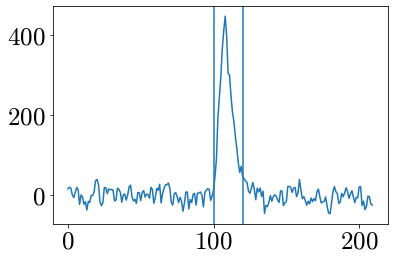

In [28]:
tres = 32.768e-6 #ms #data['delta_t (ms)']
fres = 0.03051757812 #MHz #data['delta_f (MHz)']
fres_kHz = fres*1e3

intensity_full = data #data['I']
outerbound = int(intensity_full.shape[1] * 5.5/12)
intensity_pulse = intensity_full[:, outerbound:-outerbound]
timeseries_pulse = np.nansum(intensity_pulse, axis=0)
plt.plot(timeseries_pulse)
plt.axvline(100)
plt.axvline(120)

Running example usage...

--- Analyzing 12 Sub-bands (Frequency Domain) ---
--- Analyzing Sub-band 0 (1498.8 - 1478.0 MHz) ---
--- Analyzing Sub-band 1 (1478.0 - 1461.6 MHz) ---
--- Analyzing Sub-band 2 (1461.6 - 1438.9 MHz) ---
--- Analyzing Sub-band 3 (1438.9 - 1420.9 MHz) ---
--- Analyzing Sub-band 4 (1420.9 - 1405.6 MHz) ---
--- Analyzing Sub-band 5 (1405.6 - 1392.7 MHz) ---
--- Analyzing Sub-band 6 (1392.7 - 1373.5 MHz) ---
--- Analyzing Sub-band 7 (1373.5 - 1355.5 MHz) ---
--- Analyzing Sub-band 8 (1355.5 - 1345.6 MHz) ---
--- Analyzing Sub-band 9 (1345.6 - 1329.0 MHz) ---
--- Analyzing Sub-band 10 (1328.9 - 1318.7 MHz) ---
--- Analyzing Sub-band 11 (1318.6 - 1311.2 MHz) ---

--- Analyzing Modulation Index vs Time ---


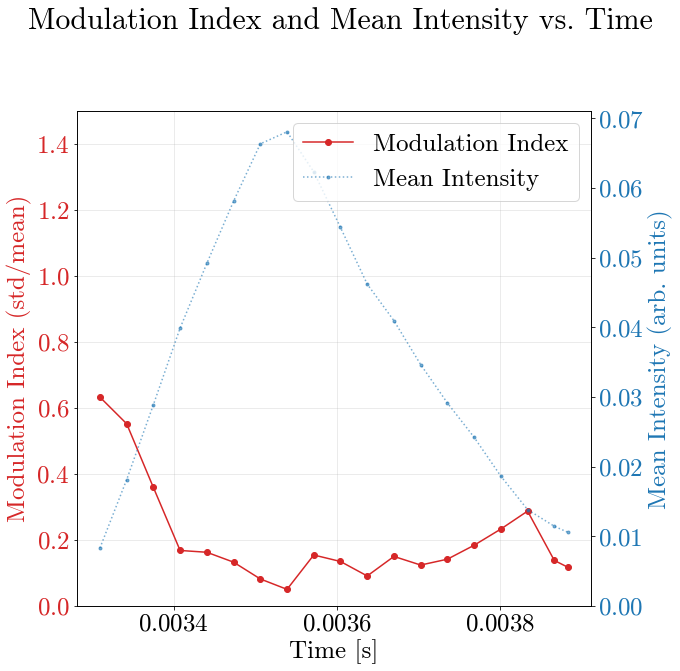


Example usage finished. Plots saved to PNG files.


In [40]:
print("Running example usage...")
# --- Generate Sample Data ---
num_freq_channels = intensity_pulse.shape[0]
num_time_samples = intensity_pulse.shape[1]
burst_start_bin = 100
burst_end_bin = 120
time_range = (burst_start_bin, burst_end_bin)
time_res_sec = tres
times_sec = np.arange(num_time_samples) * time_res_sec
freqs_mhz = np.linspace(1498.75, 1311.25, num_freq_channels)

mask = np.zeros((num_freq_channels, num_time_samples), dtype=bool)
#mask[100:150, :] = True
#mask[800:810, :] = True
dynamic_spectrum = np.ma.masked_where(mask, intensity_pulse)

# --- Frequency Analysis (as before) ---
burst_spectrum_ma = np.ma.mean(dynamic_spectrum[:, time_range[0]:time_range[1]], axis=1)
off_burst_spectrum_ma = np.ma.mean(dynamic_spectrum[:, :time_range[0]], axis=1)
num_subbands = 12
print(f"\n--- Analyzing {num_subbands} Sub-bands (Frequency Domain) ---")
subband_analysis_list = analyze_subbands(
    spectrum=burst_spectrum_ma.data,
    freqs_mhz=freqs_mhz,
    num_subbands=num_subbands,
    mask=burst_spectrum_ma.mask,
    divide_method='equal_snr',
    max_lag_mhz=5.,
    model_type='single',
    offspec_spectrum=off_burst_spectrum_ma.data, # Pass offspec data
    fit_lag_range_mhz=2.5
)

# --- Generate Plots ---

# 1. Sub-band Parameter Summary Plots
fig_fwhm, _ = plot_subband_summary(subband_analysis_list, param='fwhm_mhz')
fig_fwhm.savefig("chromatica_subband_fwhm.png")
plt.close(fig_fwhm) # Close figure to free memory

fig_mod, _ = plot_subband_summary(subband_analysis_list, param='mod_index')
fig_mod.savefig("chromatica_subband_modidx.png")
plt.close(fig_mod)

# 2. NEW: Multi-panel plot of ACF fits per sub-band
fig_acf_grid = plot_all_subband_acf_fits(subband_analysis_list)
fig_acf_grid.savefig("chromatica_subband_acf_grid.png")
plt.close(fig_acf_grid)


# --- Time Domain Analysis (as before) ---
print(f"\n--- Analyzing Modulation Index vs Time ---")
time_chunk_bins = 3
time_overlap_bins = 2
time_mod_results = analyze_modulation_over_time(
    dynamic_spectrum=dynamic_spectrum,
    times_sec=times_sec,
    burst_indices=time_range,
    time_chunk_size_bins=time_chunk_bins,
    time_overlap_bins=time_overlap_bins,
    freqs_mhz=freqs_mhz,
    freq_range_mhz=None
)

# 3. Time Analysis Plot
fig_time, _ = plot_modulation_vs_time(time_mod_results)
fig_time.savefig("wilhelm_time_modulation.png")
plt.show() # Show the last plot generated (time modulation)
plt.close(fig_time)


print("\nExample usage finished. Plots saved to PNG files.")

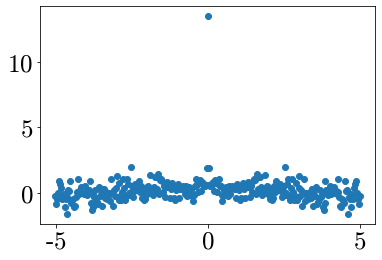

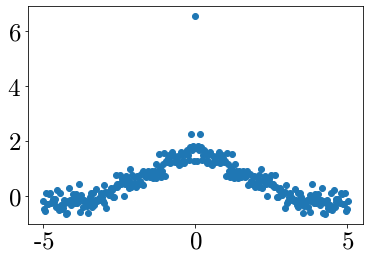

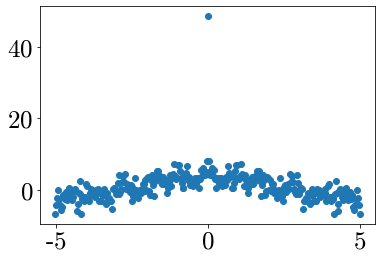

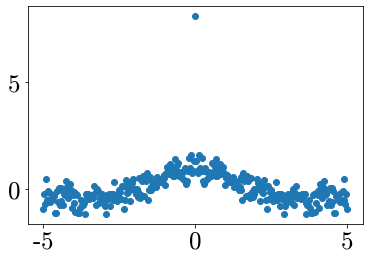

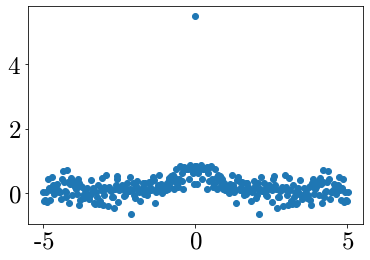

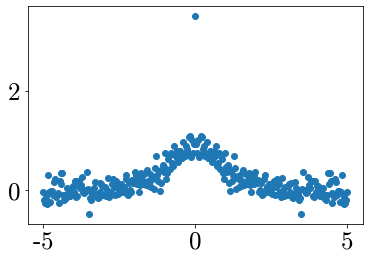

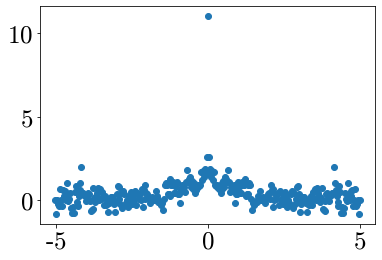

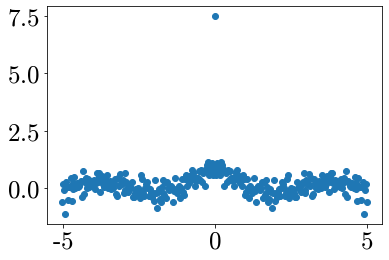

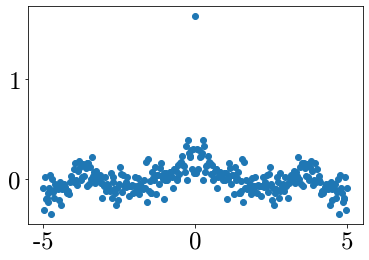

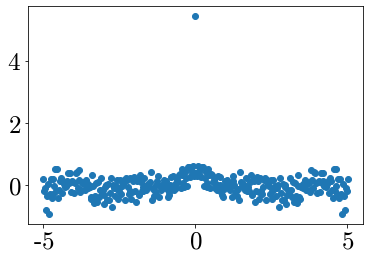

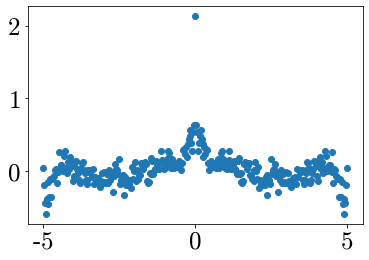

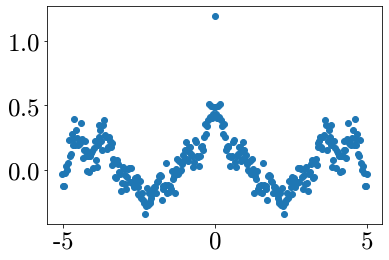

In [41]:
for i in subband_analysis_list:
    #print(i)
    plt.scatter(i['analysis_results']['lags_mhz'], i['analysis_results']['acf'])
    plt.show()
    #plt.show()

In [ ]:
tres = 32.768e-3 #ms #data['delta_t (ms)']
fres = 0.03051757812 #MHz #data['delta_f (MHz)']
fres_kHz = fres*1e3

intensity = data #data['I']
outerbound = int(intensity.shape[1] * 5/12)

intensity = intensity[:, outerbound:-outerbound]

timeseries = np.nansum(intensity, axis = 0)
timesamples = np.linspace(0, intensity.shape[1]*tres, intensity.shape[1])
timerange = np.abs(timesamples[-1] - timesamples[0])
timesamples_mod = np.linspace(-timerange/2, timerange/2, len(timesamples))
timeshift = -1 * int(timesamples_mod[np.argmax(timeseries)] / tres)

intensity = np.roll(intensity, timeshift, axis = 1)
intensity_norm = intensity / np.nanmax(intensity)
spectrum = np.nansum(intensity, axis = 1)
spectrum_norm = spectrum / np.nanmax(spectrum)
freqsamples = np.linspace(1311.25, 1498.75, intensity.shape[0])
timeseries = np.nansum(intensity, axis = 0)
timeseries_norm = timeseries / np.nanmax(timeseries)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod, timeseries_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod[0], timesamples_mod[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

mean = np.nanmean(intensity_norm)
std = np.nanstd(intensity_norm)
axes[1, 0].imshow(intensity_norm, vmin = mean - 2*std, vmax = mean + 2*std, extent = [timesamples_mod[0], timesamples_mod[-1], freqsamples[0], freqsamples[-1]], cmap = 'plasma', aspect = 'auto') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_norm), freqsamples, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples[0], freqsamples[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_fullres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [ ]:
f_factor = 380
t_factor = 1
intensity_ds = bft.downsample_data(intensity, f_factor = f_factor, t_factor = t_factor)

[<AxesSubplot:> <AxesSubplot:>]
[<AxesSubplot:> <AxesSubplot:>]


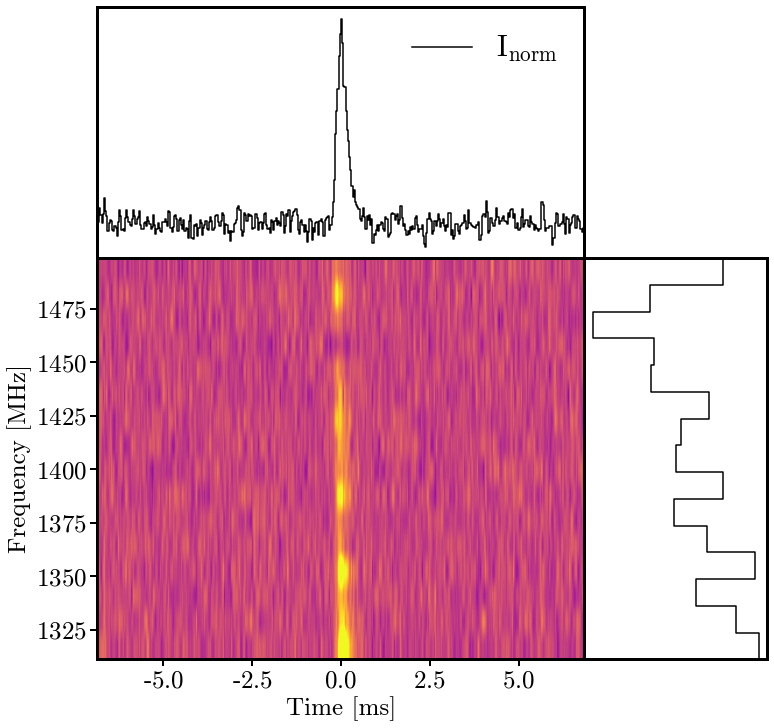

In [5]:
fres_ds = fres * f_factor
tres_ds = tres * t_factor

intensity_ds_norm = intensity_ds / np.max(intensity_ds)
timeseries_ds = np.nansum(intensity_ds, axis = 0)
timeseries_ds_norm = timeseries_ds / np.max(timeseries_ds)
timesamples_ds = np.linspace(0, intensity_ds.shape[1]*tres_ds, intensity_ds.shape[1])
timerange_ds = np.abs(timesamples_ds[-1] - timesamples_ds[0])
timesamples_mod_ds = np.linspace(-timerange_ds/2, timerange_ds/2, len(timesamples_ds))
spectrum_ds = np.nansum(intensity_ds, axis = 1)
spectrum_ds_norm = spectrum_ds / np.max(spectrum_ds)
freqsamples_ds = np.linspace(1311.25, 1498.75, intensity_ds.shape[0])

spectrum = np.nansum(intensity_ds, axis = 1)
timeseries = np.nansum(intensity_ds, axis = 0)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod_ds, timeseries_ds_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod_ds[0], timesamples_mod_ds[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
axes[1, 0].imshow(intensity_ds_norm, vmin = mean_ds - 6*std_ds, vmax = mean_ds + 6*std_ds, extent = [timesamples_mod_ds[0], timesamples_mod_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]], cmap = 'plasma', aspect = 'auto') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_lowres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [6]:
n_channels = intensity_ds.shape[0]
n_samples = intensity_ds.shape[1]

# Create time array (ms)
time = np.linspace(0, n_samples*tres_ds, n_samples)

# Create frequency array with 128 channels
f_b = 1.31125  # GHz
f_t = 1.49875    # GHz
freq = np.linspace(f_b, f_t, n_channels)

# Set parameters for Model 3
#c0 = 1.0  # Reference flux at reference frequency
#spectral_index = 2.5
#t0 = 1.0  # ms
dm_init = 0.0
#DM_err = 0.0
#zeta = 0.08
#tau_1GHz = 0.6
#alpha = 4.0

# Parameters array for model 3
#params = [c0, spectral_index, t0, DM_err, zeta, tau_1GHz, alpha]

# Initialize the model and data
#data = np.zeros((N_channels, N_time_samples))
model_instance = bft.FRBModel(intensity_ds_norm, time, freq, dm_init)

# Add Gaussian noise to the simulated data
#np.random.seed(42)  # For reproducibility
#noise_level = 0.05 * np.max(simulated_data)  # Adjust noise level as needed
#noise = noise_level * np.random.randn(*simulated_data.shape)
#simulated_data_noisy = simulated_data + noise
#simulated_data_timeseries = simulated_data_noisy.sum(0) / np.max(simulated_data_noisy.sum(0))

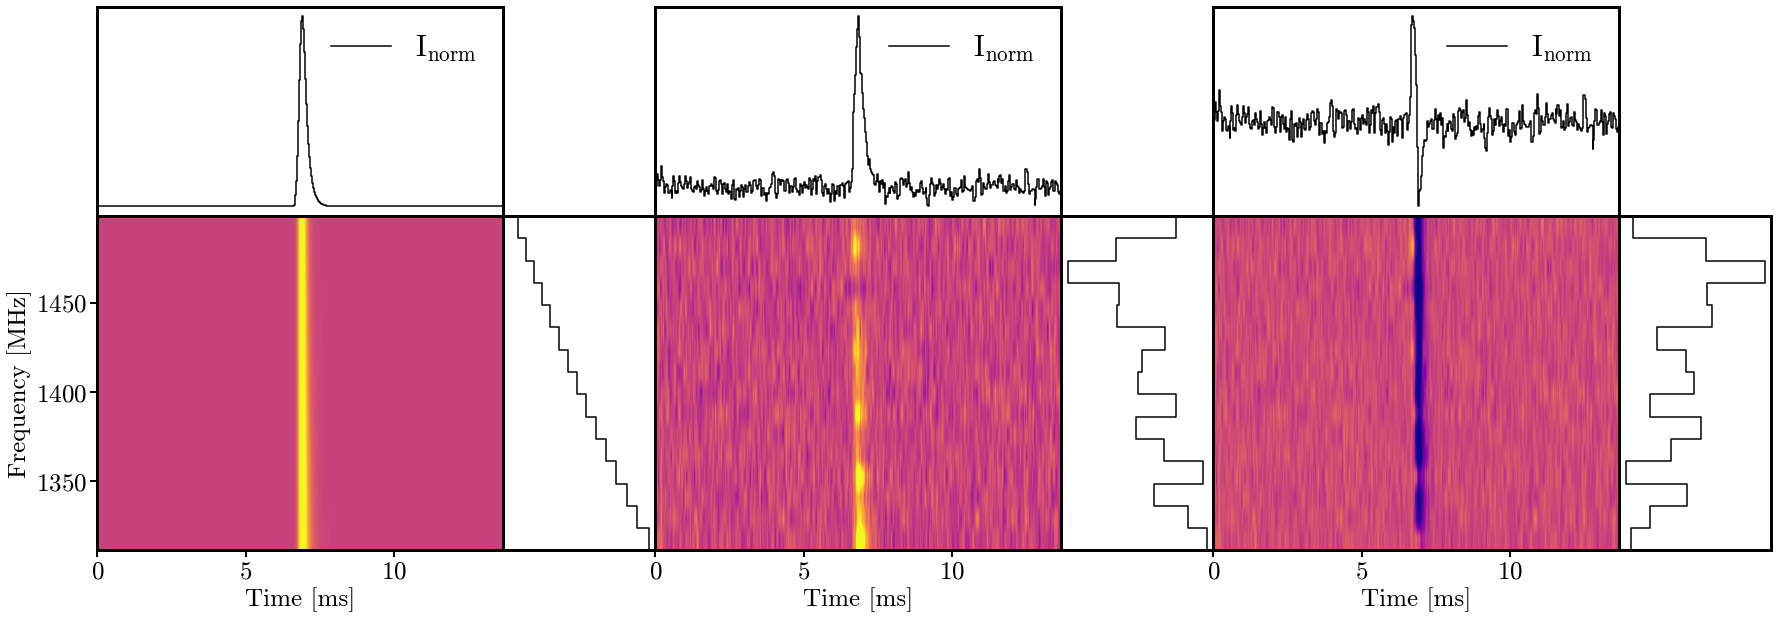

In [7]:
# --- (Assuming the simulated data and real data arrays have already been defined) ---

# Generate simulated data (as in your original code)
c0_init = np.max(np.sum(intensity_ds_norm, axis=1)) / intensity_ds_norm.shape[1]
t0_init = timesamples_ds[np.argmax(np.sum(intensity_ds_norm, axis=0))]
gamma_init = -2
DM_err_init = 0.0
zeta_init = 0.08
tau_init = 0.5
alpha_init = 4.0

model_type = 'model3'
if model_type == 'model0':
    sim_params = [c0_init, t0_init, gamma_init, DM_err_init, 0., 0., 0.]
elif model_type == 'model1':
    sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, 0., 0.]
elif model_type == 'model2':
    sim_params = [c0_init, t0_init, gamma_init, DM_err_init, tau_init, alpha_init, 0.]
elif model_type == 'model3':
    sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, tau_init, alpha_init]

simulated_data = model_instance.model(sim_params, model_type=model_type)
simulated_data_norm = simulated_data / np.max(simulated_data)

sim_fres = fres_ds
sim_tres = tres_ds
sim_timeseries = np.nansum(simulated_data, axis=0)
sim_timeseries_norm = sim_timeseries / np.max(sim_timeseries)
sim_timesamples = np.linspace(0, simulated_data.shape[1]*sim_tres, simulated_data.shape[1])
sim_timerange = np.abs(sim_timesamples[-1] - sim_timesamples[0])
sim_timesamples_mod = np.linspace(-sim_timerange/2, sim_timerange/2, len(sim_timesamples))
sim_spectrum = np.nansum(simulated_data, axis=1)
sim_spectrum_norm = sim_spectrum / np.max(sim_spectrum)
sim_freqsamples = np.linspace(1311.25, 1498.75, simulated_data.shape[0])

# Compute residuals and residual spectrum
intensity_rsdl = intensity_ds_norm - simulated_data_norm
timeseries_rsdl = timeseries_ds_norm - sim_timeseries_norm
rsdl_spectrum = np.nansum(intensity_rsdl, axis=1)
rsdl_spectrum_norm = rsdl_spectrum / np.max(rsdl_spectrum)

# Precompute means and stds for imshow scaling
sim_mean = np.nanmean(simulated_data_norm)
sim_std = np.nanstd(simulated_data_norm)
mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
mean_rsdl = np.nanmean(intensity_rsdl)
std_rsdl = np.nanstd(intensity_rsdl)

# Create a figure with 2 rows x 6 columns:
# Columns 0-1: Panel 1 (Simulated/Model)
# Columns 2-3: Panel 2 (Real Data)
# Columns 4-5: Panel 3 (Residual)
fig, axes = plt.subplots(
    nrows=2, ncols=6, sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1.25, 2],
                 'width_ratios': [2, 0.75, 2, 0.75, 2, 0.75]},
    figsize=(30, 10)
)

# Increase border thickness and set tick parameters for every axis
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis='y', length=5)

# ----- PANEL 1: Simulated Data (Model) -----
# Timeseries (top left of panel 1: column 0)
axes[0, 0].step(sim_timesamples, sim_timeseries_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([])
axes[0, 0].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 0].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 0].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 0].imshow(simulated_data_norm,
                   vmin=sim_mean - 6*sim_std, vmax=sim_mean + 6*sim_std,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 1: column 1)
axes[1, 1].step(np.flip(sim_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 1].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

# ----- PANEL 2: Real Data -----
# Timeseries (top left of panel 2: column 2)
axes[0, 2].step(timesamples_ds, timeseries_ds_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 2].set_yticks([])
axes[0, 2].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 2].set_xlim(timesamples_ds[0], timesamples_ds[-1])
axes[0, 2].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 2: column 2)
axes[1, 2].imshow(intensity_ds_norm,
                   vmin=mean_ds - 6*std_ds, vmax=mean_ds + 6*std_ds,
                   extent=[timesamples_ds[0], timesamples_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 2].set_ylabel('Frequency [MHz]')
axes[1, 2].set_yticks([])
axes[1, 2].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 2: column 3)
axes[1, 3].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 3].set_xlabel('Intensity')
axes[1, 3].set_xticks([])
axes[1, 3].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
axes[1, 3].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 3)
axes[0, 3].axis('off')
axes[0, 3].set_visible(False)

# ----- PANEL 3: Residuals -----
# Timeseries residual (top left of panel 3: column 4)
axes[0, 4].step(sim_timesamples, timeseries_rsdl, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 4].set_yticks([])
axes[0, 4].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 4].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 4].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall residual (bottom left of panel 3: column 4)
axes[1, 4].imshow(intensity_rsdl,
                   vmin=mean_rsdl - 6*std_rsdl, vmax=mean_rsdl + 6*std_rsdl,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 4].set_ylabel('Frequency [MHz]')
axes[1, 4].set_yticks([])
axes[1, 4].set_xlabel('Time [ms]')

# Spectrum for residuals (bottom right of panel 3: column 5)
axes[1, 5].step(np.flip(rsdl_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 5].set_xlabel('Intensity')
axes[1, 5].set_xticks([])
axes[1, 5].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 5].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 5)
axes[0, 5].axis('off')
axes[0, 5].set_visible(False)
plt.subplots_adjust(hspace=0, wspace=0)

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_initmodel_threepanel.pdf', bbox_inches = 'tight')

plt.show()


In [56]:
# Fit the models
prior_bounds = {
        'c0': (1e-3, 100),  # Adjusted as per prior
        't0': (t0_init - 2, t0_init + 2),
        'spectral_index': (-5, 5),
        'DM_err': (-0.001, 0.001),
        'zeta': (0, 0.5),
        'tau_1GHz': (0, 1.),
        'alpha': (3.999999999999, 4.00000000001)
    }

nsteps = 500


results, best_model = bft.fit_models(model_instance, sim_params, prior_bounds, numsteps=nsteps, fit_m0=False, fit_m1=False, fit_m2=False, fit_m3=True)
print(f"The best-fitting model is: {best_model}")

Check Prior Bounds:  {'c0': (0.001, 100), 't0': (4.864935290167866, 8.864935290167866), 'spectral_index': (-5, 5), 'DM_err': (-0.001, 0.001), 'zeta': (0, 0.5), 'tau_1GHz': (0, 1.0), 'alpha': (3.999999999999, 4.00000000001)}
Fitting Model 3


  0%|          | 1/500 [00:00<01:26,  5.78it/s]100%|██████████| 500/500 [01:57<00:00,  4.25it/s]

Best model is model3
The best-fitting model is: model3


In [57]:
# Extract the sampler
best_sampler = results[best_model]['sampler']

print("Mean acceptance fraction (should be 0.2-0.5):", np.mean(best_sampler.acceptance_fraction))

# Check for NaN or Inf in Sampler
log_probs = best_sampler.get_log_prob()
if np.any(~np.isfinite(log_probs)):
    print("Found NaN or Inf in log-probabilities.")

#samples = best_sampler.get_chain(flat=True)
# Discard burn-in samples
burn_in = nsteps // 2
# Extract the samples
samples = best_sampler.get_chain(discard=burn_in, flat=True)
# Extract the log probability
log_prob = best_sampler.get_log_prob(discard=burn_in, flat=True)

# Determine the indices of the relevant parameters
if best_model == 'model0':
    param_indices = [0, 1, 2, 3]  # c0, spectral_index, t0, DM_err
elif best_model == 'model1':
    param_indices = [0, 1, 2, 3, 4]  # + zeta
elif best_model == 'model2':
    param_indices = [0, 1, 2, 3, 4, 5]  # + tau_1GHz, alpha
elif best_model == 'model3':
    param_indices = [0, 1, 2, 3, 4, 5, 6]  # + zeta, tau_1GHz, alpha

# Extract the relevant samples
relevant_samples = samples[:, param_indices]

# Extract the relevant true parameter values
#truths = [params[i] for i in param_indices]

# Define labels for the parameters
labels = ['c0', 't0', 'spectral_index', 'DM_err']
if best_model in ['model1', 'model3']:
    labels.append('zeta')
if best_model in ['model2', 'model3']:
    labels.extend(['tau_1GHz', 'alpha'])

# Plot trace plots to assess convergence
#ndim = relevant_samples.shape[1]
#fig, axes = plt.subplots(ndim, figsize=(15, 10), sharex=True)
#for i in range(ndim):
#    axes[i].plot(samples[:, i], "k", alpha=0.3)
#    axes[i].set_ylabel(labels[i])
#axes[-1].set_xlabel("Step number")
#plt.show()

Mean acceptance fraction (should be 0.2-0.5): 0.2911142857142857


In [58]:
# Calculate parameter estimates and their uncertainties
best_fit_params = []
best_fit_params_dict = {}
for i, label in enumerate(labels):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{label} = {mcmc[1]:.3f} (+{q[1]:.3f}, -{q[0]:.3f})")
    best_fit_params.append(mcmc[1])
    best_fit_params_dict[f'{label}'] = (mcmc[1], +q[1], -q[0])

# Generate simulated data
initial_params = {}
initial_params['c0_init'] = c0_init
initial_params['t0_init'] = t0_init
initial_params['gamma_init'] = gamma_init
initial_params['DM_err_init'] = DM_err_init
initial_params['zeta_init'] = zeta_init
initial_params['tau_init'] = tau_init
initial_params['alpha_init'] = alpha_init

best_fit_params_dict['initial_params'] = initial_params
best_fit_params_dict['prior_bounds'] = prior_bounds


c0 = 0.003 (+0.000, -0.000)
t0 = 6.796 (+0.010, -0.007)
spectral_index = -4.958 (+0.255, -0.033)
DM_err = 0.000 (+0.001, -0.001)
zeta = 0.098 (+0.006, -0.007)
tau_1GHz = 0.465 (+0.040, -0.047)
alpha = 4.000 (+0.000, -0.000)


Best Fit Params: [ 3.44440016e-03  6.79796722e+00 -4.99504124e+00  8.28351310e-04
  1.00164847e-01  4.25463093e-01  4.00000000e+00]


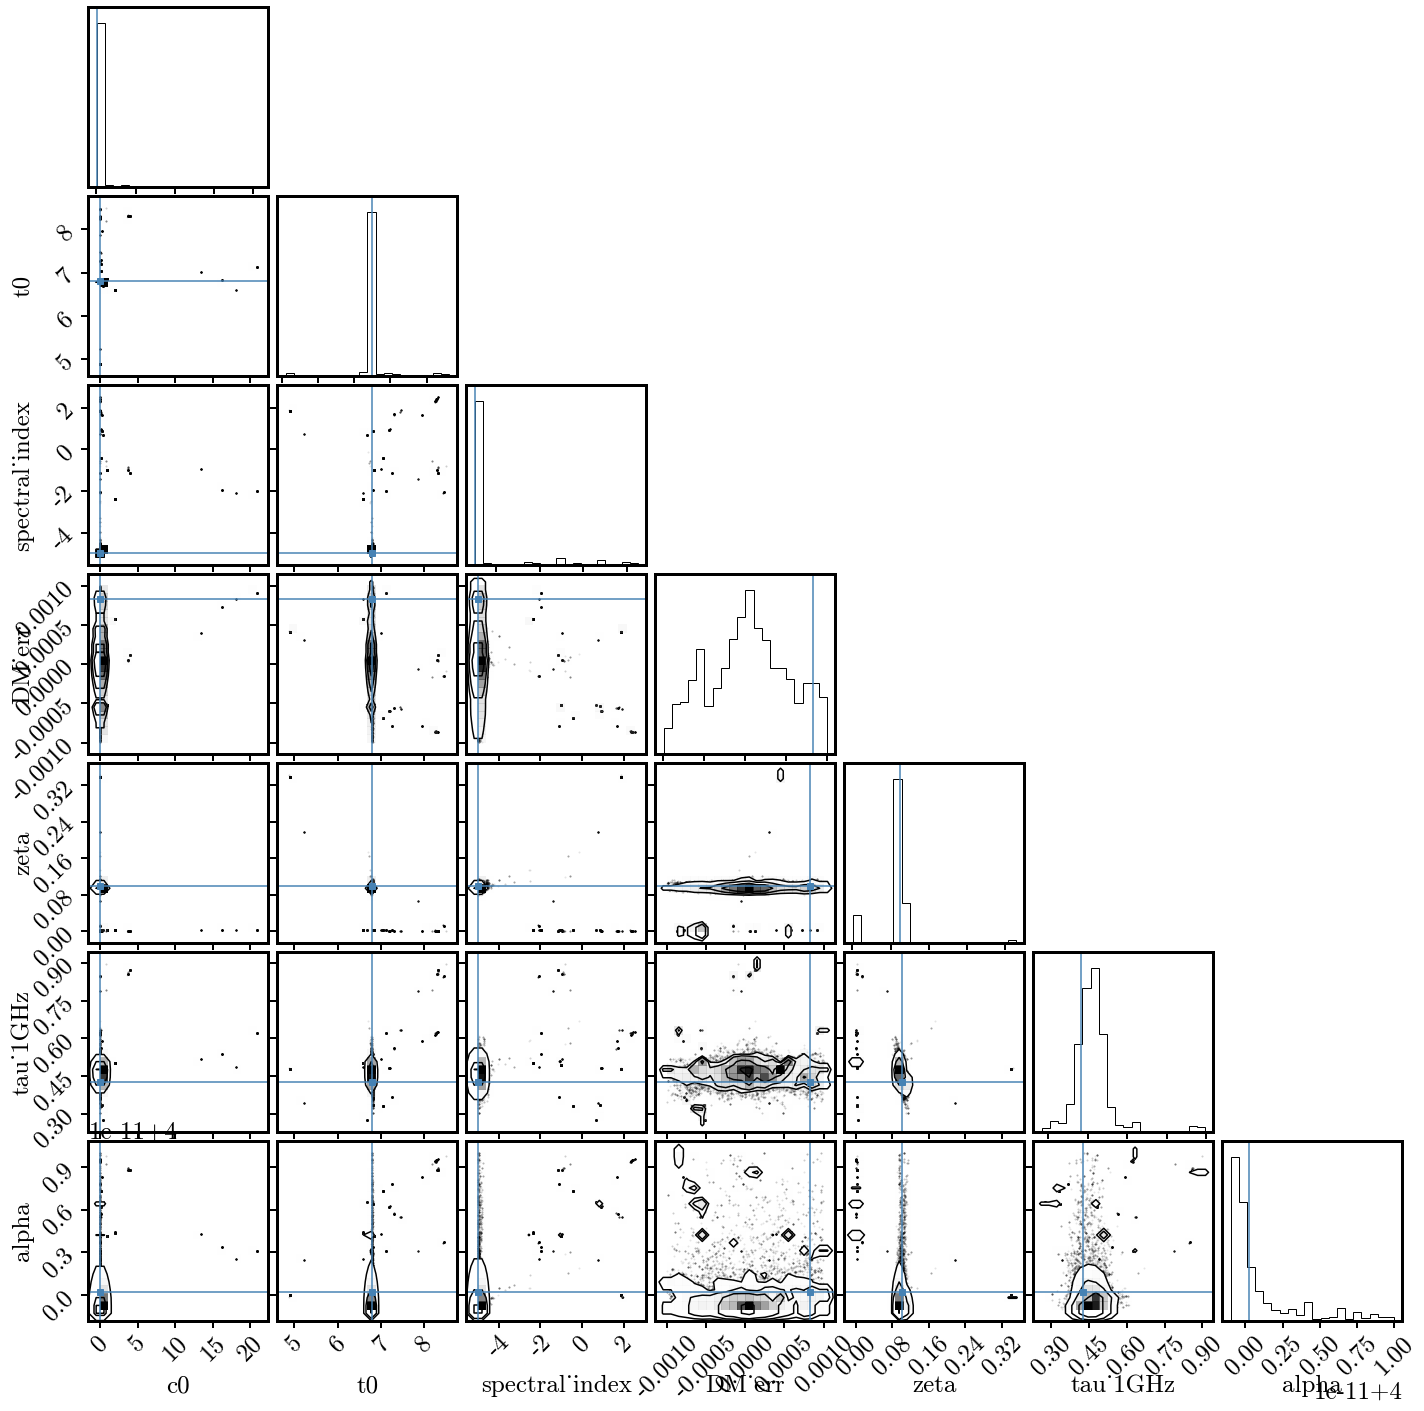

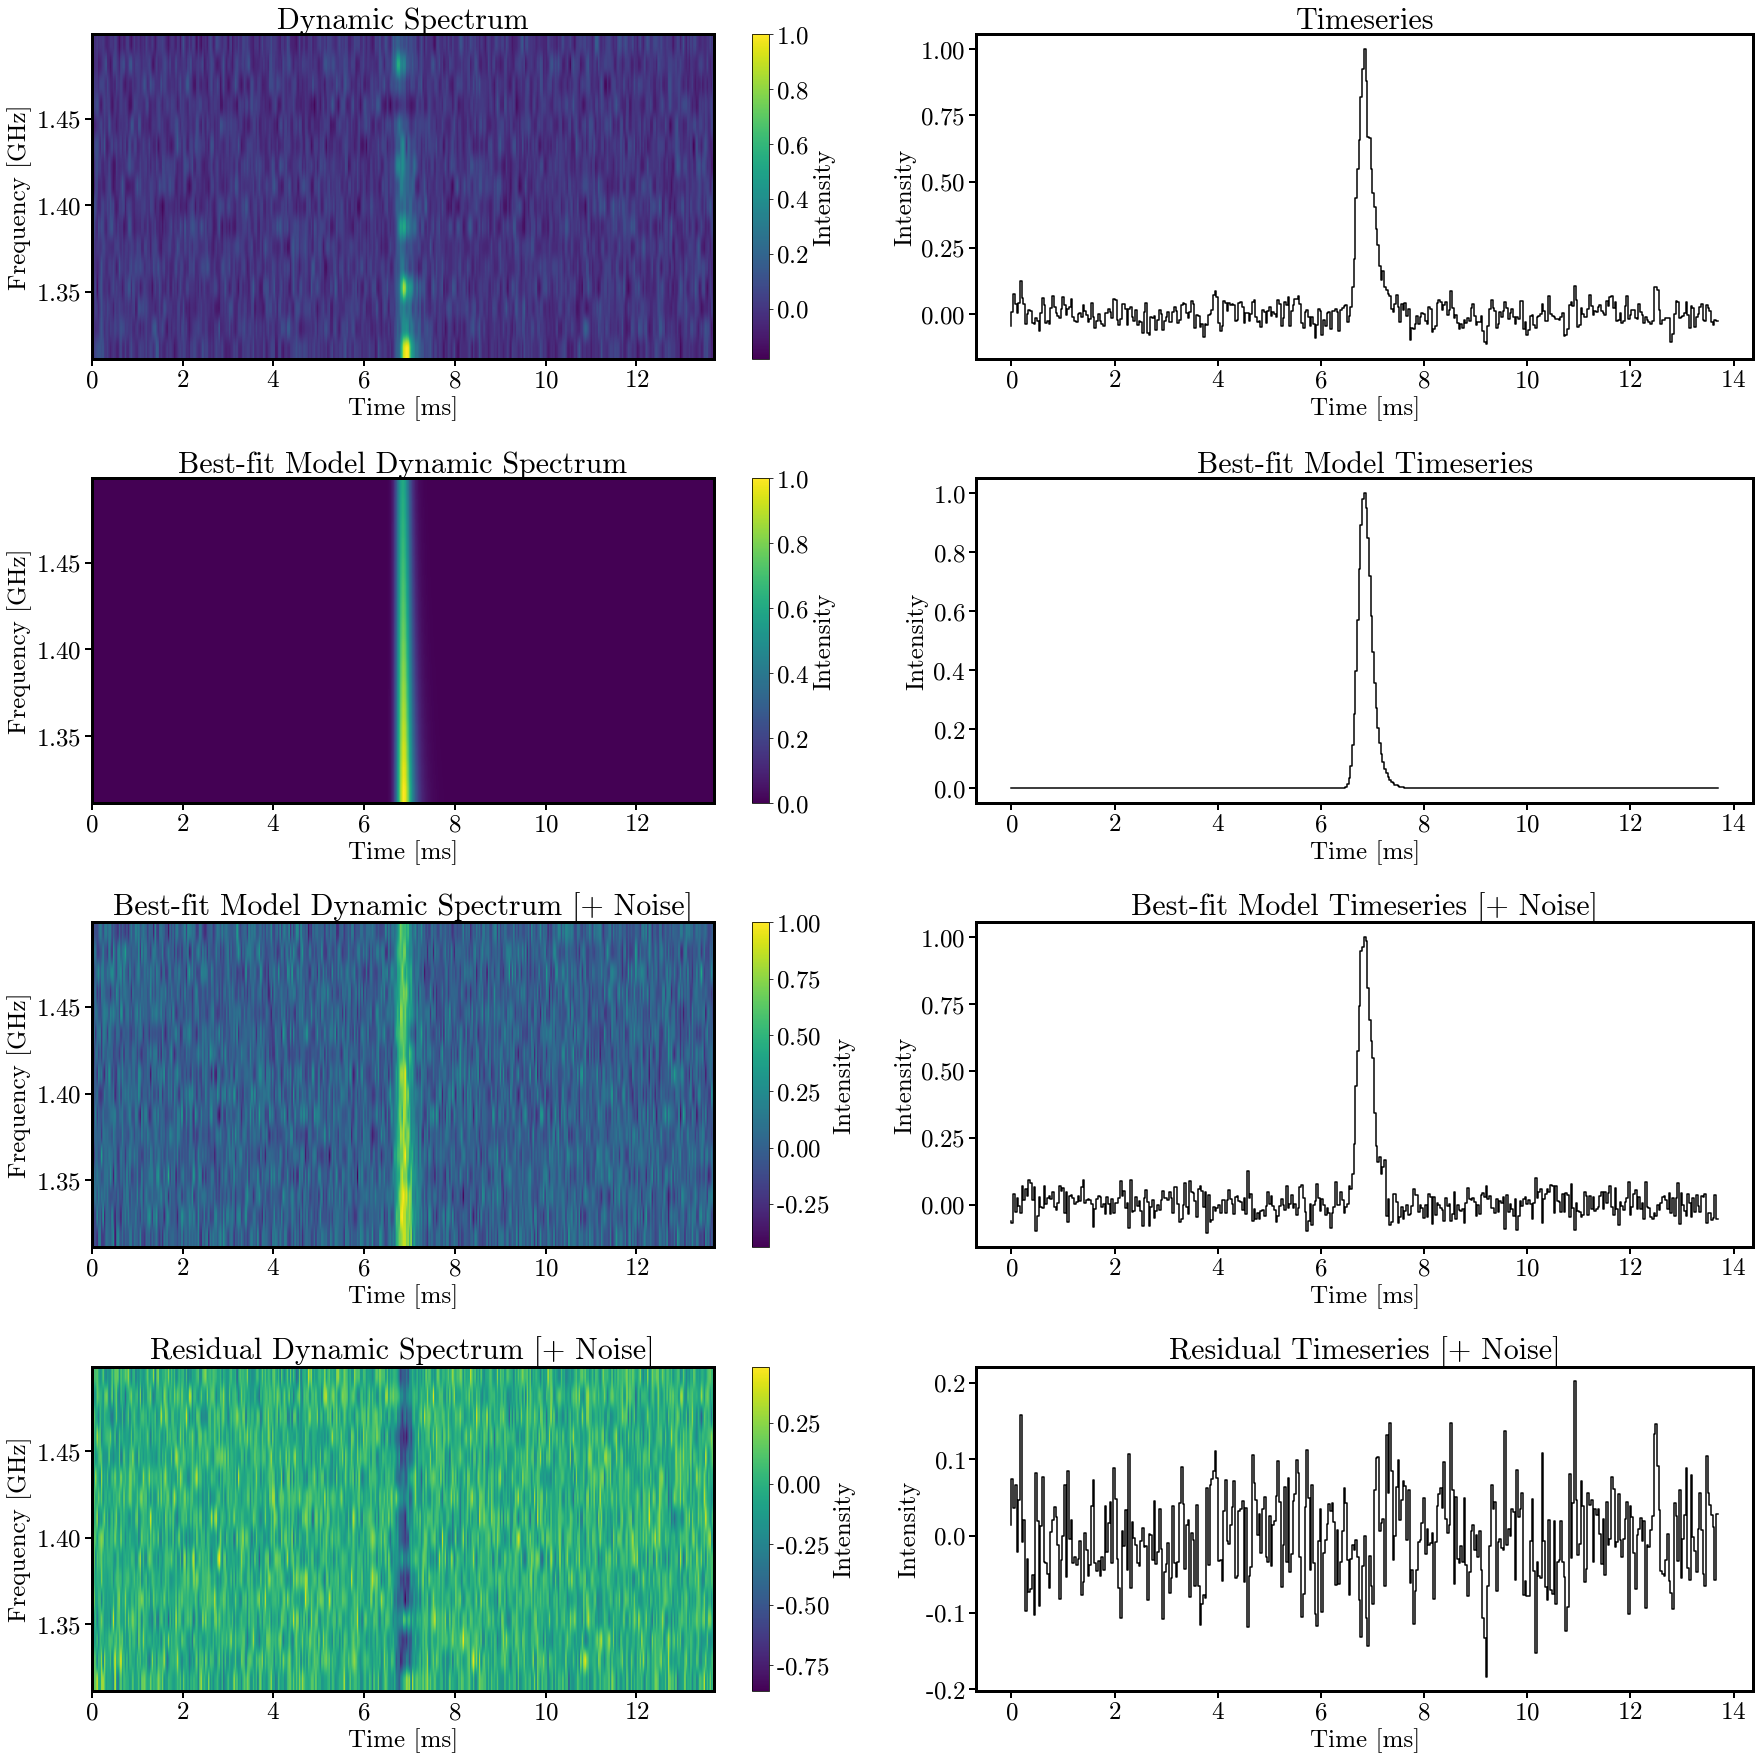

Mean acceptance fraction: 0.2911142857142857


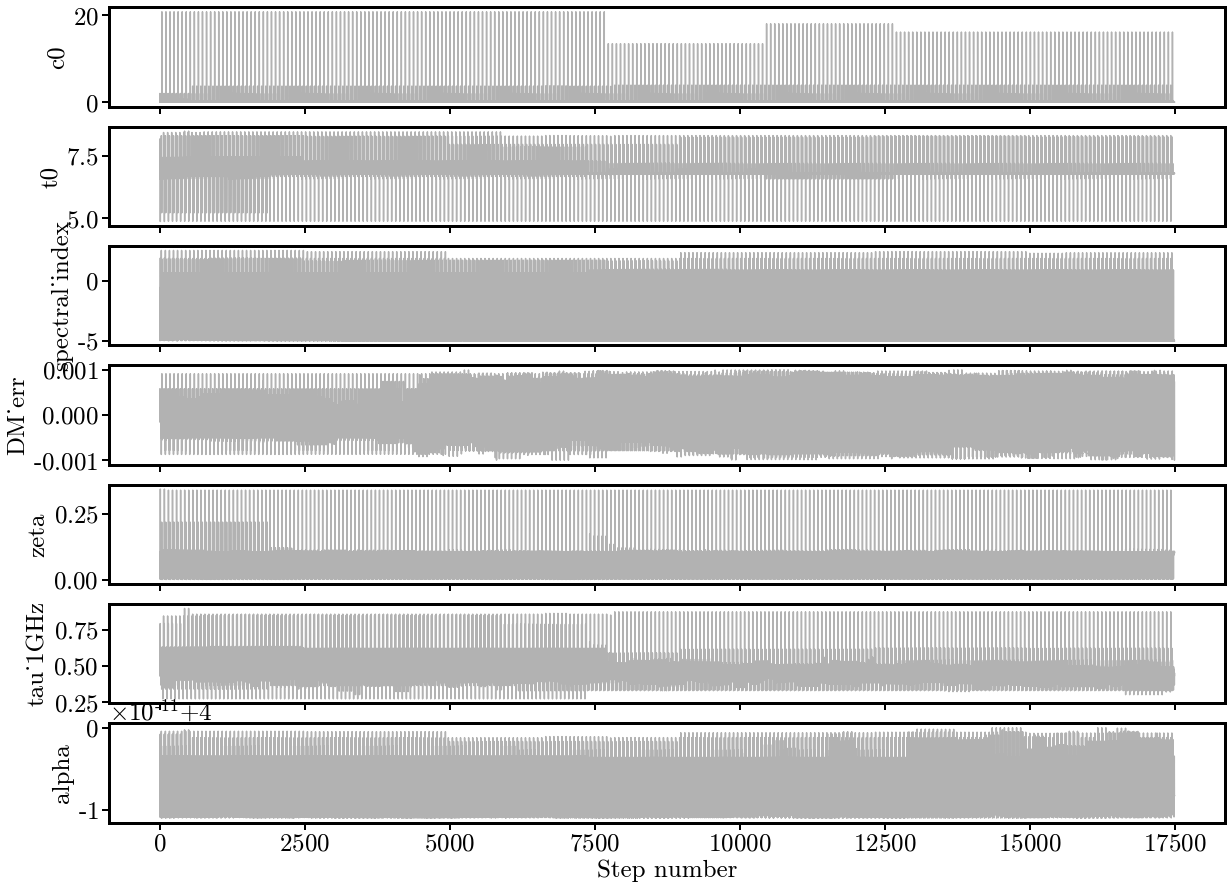

In [75]:
# Plot the data and the best-fit model
best_fit_index = np.argmax(best_sampler.get_log_prob(discard=burn_in, flat=True))
best_fit_index = np.argmax(log_prob)
best_fit_params = samples[best_fit_index]

print(f'Best Fit Params: {best_fit_params}')

# Plot the corner plot
# Define figure size before creating the corner plot
fig = plt.figure(figsize=(20, 20))  # Adjust width and height

fig = corner.corner(relevant_samples, labels=labels, truths=best_fit_params, fig=fig)

for ax in fig.axes:
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_corner.pdf', bbox_inches = 'tight')
plt.show()

# Compute the model spectrum using the best-fit parameters
best_fit_model = model_instance.model(best_fit_params, model_type=best_model)

# Normalized data
norm_data = model_instance.data / np.max(model_instance.data)
norm_data_timeseries = model_instance.data.sum(0) / np.max(model_instance.data.sum(0))

# Normalized model
norm_model = best_fit_model / np.max(best_fit_model)
norm_model_timeseries = best_fit_model.sum(0) / np.max(best_fit_model.sum(0))

# Plot the data and the best-fit model separately for comparison
fig = plt.figure(figsize=(25, 25))

for i in range(1, 9):
    plt.subplot(4, 2, i)
    ax = plt.gca()
    
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)

# Plot the data
plt.subplot(4, 2, 1)
extent = [time[0], time[-1], freq[0], freq[-1]]
plt.imshow(norm_data, extent=extent, aspect='auto', origin='upper', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Dynamic Spectrum')

plt.subplot(4, 2, 2)
plt.step(time, norm_data_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Intensity')
plt.title('Timeseries')

# Plot the best-fit model
plt.subplot(4, 2, 3)
plt.imshow(norm_model, extent=extent, aspect='auto', origin='upper', cmap='viridis')
#plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum')

plt.subplot(4, 2, 4)
plt.step(time, norm_model_timeseries, c='k')
#plt.plot(time, norm_noisy_timeseries)
plt.xlabel('Time [ms]')
plt.ylabel('Intensity')
plt.title('Best-fit Model Timeseries')

# Plot the best-fit model with added noise (based on the original data)
# Generate synthetic noise with the same shape as the model
noise = np.random.normal(loc=0.0, scale=model_instance.noise_std[:, np.newaxis], size=best_fit_model.shape)

# Add the synthetic noise to the fitted model
noisy_model = best_fit_model + noise
norm_noisy_model = noisy_model / np.max(noisy_model)

# Integrate to get the noisy timeseries
noisy_timeseries = np.nansum(norm_noisy_model, axis = 0)
norm_noisy_timeseries = noisy_timeseries / np.max(noisy_timeseries)

plt.subplot(4, 2, 5)
#plt.imshow(norm_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 6)
#plt.plot(time, norm_model_timeseries)
plt.step(time, norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Intensity')
plt.title('Best-fit Model Timeseries [+ Noise]')

# Plot the residuals
plt.subplot(4, 2, 7)
plt.imshow(norm_data - norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Residual Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 8)
plt.step(time, norm_data_timeseries - norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Intensity')
plt.title('Residual Timeseries [+ Noise]')

plt.tight_layout()

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_finalmodel_eightpanel.pdf', bbox_inches = 'tight')

plt.show()

# Check the mean acceptance fraction
print("Mean acceptance fraction:", np.mean(best_sampler.acceptance_fraction))

# Trace plots to assess convergence
ndim = len(labels)
fig, axes = plt.subplots(ndim, figsize=(20, 15), sharex=True)
for i in range(ndim):
    axes[i].plot(samples[:, i], "k", alpha=0.3)
    axes[i].set_ylabel(labels[i])
    # Spine widths
    axes[i].spines['top'].set_linewidth(3)
    axes[i].spines['bottom'].set_linewidth(3)
    axes[i].spines['left'].set_linewidth(3)
    axes[i].spines['right'].set_linewidth(3)

    # Tick parameters
    axes[i].tick_params(which='both', width=2)
    axes[i].tick_params(which='major', length=7)
    axes[i].tick_params(which='minor', length=5)
    axes[i].tick_params(which='minor', axis='y', length=5)
axes[-1].set_xlabel("Step number")

fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_traces.pdf', bbox_inches = 'tight')

plt.show()


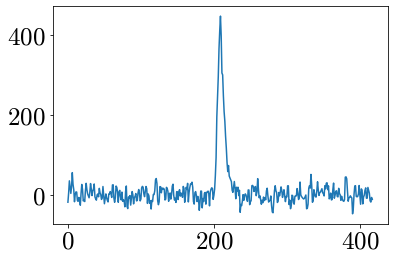

In [4]:
off

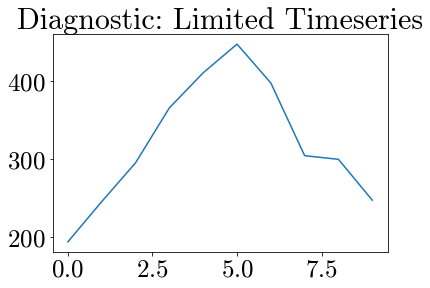

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6144/6144 [00:01<00:00, 6003.97it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 112
    # data points      = 262
    # variables        = 3
    chi-square         = 1.12712876
    reduced chi-square = 0.00435185
    Akaike info crit   = -1421.55181
    Bayesian info crit = -1410.84678
    R-squared          = 0.95894679
[[Variables]]
    gamma1:  1581.65065 +/- 46.6789748 (2.95%) (init = 1)
    m1:      1.06289560 +/- 0.00737908 (0.69%) (init = 1)
    c:       0.04762067 +/- 0.01611256 (33.84%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, c)  = -0.8730
    C(m1, c)      = -0.7158
    C(gamma1, m1) = +0.3777


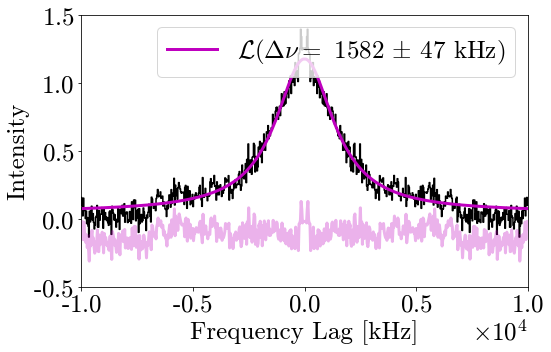

In [7]:
#spec_norm = spectrum / np.max(spectrum)
intensity_tshape = intensity.shape[1]
intensity_off = intensity[:, 0:150]
offspec_mean = np.nanmean(intensity_off)
outer_bound = 5
spectrum_lim = np.nansum(intensity[:, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=1)

fig = plt.figure()
plt.plot(np.nansum(intensity[:, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=0))
plt.title('Diagnostic: Limited Timeseries')
plt.show()

spec_norm = spectrum_lim #/ np.max(spectrum_lim)
acf=sct.autocorr(spec_norm, offspec_mean = offspec_mean)
lags=np.arange(len(acf))+1
acf=acf[1:]
lags=lags[1:]
acf=np.concatenate((acf[::-1],acf))
lags=np.concatenate((-1*lags[::-1],lags))*fres_kHz

lag_range_for_fit=4000 #somewhat arbitrary, 2000 works well to successfully fit the central peak

gmodel = Model(sct.lorentz)
acf_for_fit = acf[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
lags_for_fit = lags[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
#result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=10, m1=1,gamma2=100,m2=1, c=0)
result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=1, m1=1,c=0)
print(result.fit_report())

fig = plt.figure(figsize = (8, 5))

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((-4, 4))

label_str = r'$\mathcal{L}(\Delta \nu =$ ' + str(round(result.params['gamma1'].value)) + r' $\pm$ ' + str(round(result.params['gamma1'].stderr)) + ' kHz)'


plt.step(lags, acf, c = 'k')
plt.plot(lags, sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']), c = 'm', lw = 3, label = label_str)
plt.plot(lags, acf - sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']) - 0.1, c = 'm', alpha = 0.3, lw = 3)

plt.xlim(-10e3, 10e3)
plt.ylim(-0.5, 1.5)
plt.xlabel('Frequency Lag [kHz]')
plt.ylabel('Intensity')
plt.legend()
fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_acf_fit.pdf', bbox_inches = 'tight')
plt.show()

LIM: 0 to 1536


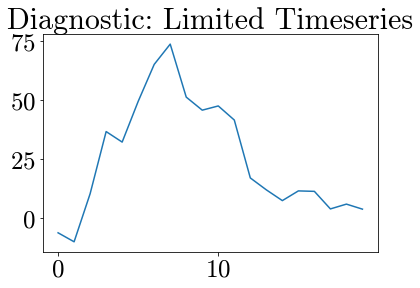

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1536/1536 [00:00<00:00, 9076.50it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 170
    # data points      = 130
    # variables        = 3
    chi-square         = 0.05486269
    reduced chi-square = 4.3199e-04
    Akaike info crit   = -1004.15931
    Bayesian info crit = -995.556706
    R-squared          = 0.55187787
[[Variables]]
    gamma1:  3163.09710 +/- 1704.96246 (53.90%) (init = 1)
    m1:      0.50262660 +/- 0.20082579 (39.96%) (init = 1)
    c:      -0.08521165 +/- 0.20400824 (239.41%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = -0.9999
    C(gamma1, c)  = -0.9961
    C(gamma1, m1) = +0.9950


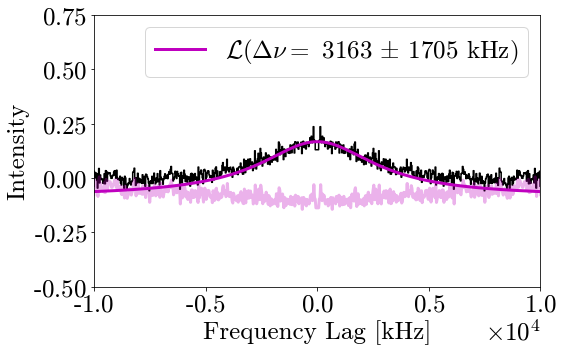

LIM: 1 to 1537


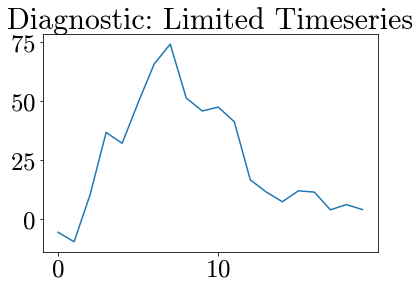

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1536/1536 [00:00<00:00, 9388.86it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 170
    # data points      = 130
    # variables        = 3
    chi-square         = 0.05477105
    reduced chi-square = 4.3127e-04
    Akaike info crit   = -1004.37663
    Bayesian info crit = -995.774022
    R-squared          = 0.54829388
[[Variables]]
    gamma1:  2991.78891 +/- 1503.60030 (50.26%) (init = 1)
    m1:      0.48075284 +/- 0.17390304 (36.17%) (init = 1)
    c:      -0.06316039 +/- 0.16933752 (268.11%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = -0.9998
    C(gamma1, c)  = -0.9953
    C(gamma1, m1) = +0.9938


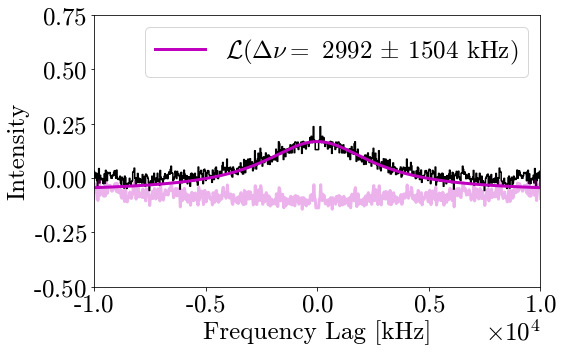

LIM: 2 to 1538


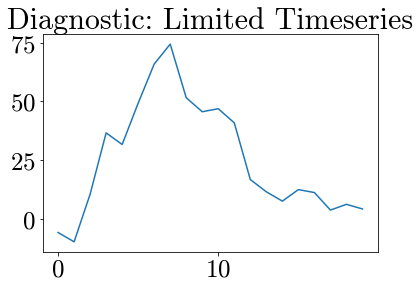

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1536/1536 [00:00<00:00, 7360.75it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 166
    # data points      = 130
    # variables        = 3
    chi-square         = 0.05398923
    reduced chi-square = 4.2511e-04
    Akaike info crit   = -1006.24567
    Bayesian info crit = -997.643062
    R-squared          = 0.55127534
[[Variables]]
    gamma1:  2907.61981 +/- 1397.11910 (48.05%) (init = 1)
    m1:      0.47084311 +/- 0.16024780 (34.03%) (init = 1)
    c:      -0.05367025 +/- 0.15300188 (285.08%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = -0.9998
    C(gamma1, c)  = -0.9948
    C(gamma1, m1) = +0.9931


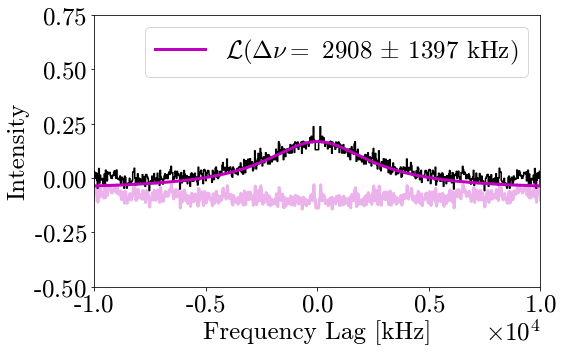

LIM: 3 to 1539


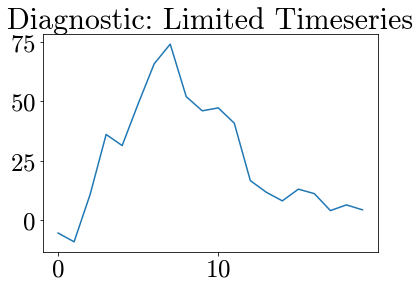

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1536/1536 [00:00<00:00, 9061.13it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 166
    # data points      = 130
    # variables        = 3
    chi-square         = 0.05396043
    reduced chi-square = 4.2489e-04
    Akaike info crit   = -1006.31503
    Bayesian info crit = -997.712423
    R-squared          = 0.55166111
[[Variables]]
    gamma1:  2884.20312 +/- 1370.14807 (47.51%) (init = 1)
    m1:      0.46829884 +/- 0.15684668 (33.49%) (init = 1)
    c:      -0.05134857 +/- 0.14900825 (290.19%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = -0.9998
    C(gamma1, c)  = -0.9947
    C(gamma1, m1) = +0.9928


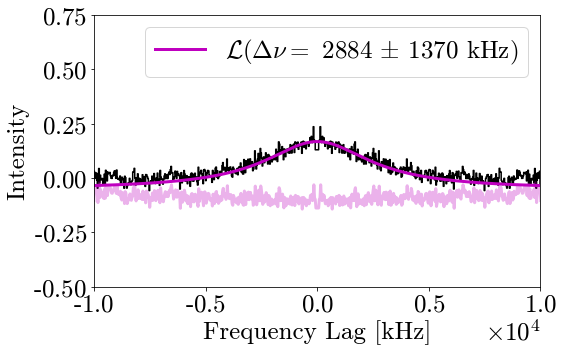

In [8]:
#spec_norm = spectrum / np.max(spectrum)
for i in np.arange(0, 6):
    print(f'LIM: {i} to {i+1536}')
    intensity_tshape = intensity.shape[1]
    intensity_lim = intensity[i:i+1536, :]
    outer_bound = 10
    spectrum_lim = np.nansum(intensity_lim[:, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=1)

    fig = plt.figure()
    plt.plot(np.nansum(intensity_lim[:, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=0))
    plt.title('Diagnostic: Limited Timeseries')
    plt.show()

    spec_norm = spectrum_lim / np.max(spectrum_lim)
    acf=sct.autocorr(spec_norm, zerolag=False)
    lags=np.arange(len(acf))+1
    acf=acf[1:]
    lags=lags[1:]
    acf=np.concatenate((acf[::-1],acf))
    lags=np.concatenate((-1*lags[::-1],lags))*fres_kHz

    lag_range_for_fit=2000 #somewhat arbitrary, 2000 works well to successfully fit the central peak

    gmodel = Model(sct.lorentz)
    acf_for_fit = acf[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    lags_for_fit = lags[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    #result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=10, m1=1,gamma2=100,m2=1, c=0)
    result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=1, m1=1,c=0)
    print(result.fit_report())

    fig = plt.figure(figsize = (8, 5))

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((-4, 4))

    label_str = r'$\mathcal{L}(\Delta \nu =$ ' + str(round(result.params['gamma1'].value)) + r' $\pm$ ' + str(round(result.params['gamma1'].stderr)) + ' kHz)'


    plt.step(lags, acf, c = 'k')
    plt.plot(lags, sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']), c = 'm', lw = 3, label = label_str)
    plt.plot(lags, acf - sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']) - 0.1, c = 'm', alpha = 0.3, lw = 3)

    plt.xlim(-10e3, 10e3)
    plt.ylim(-0.5, 0.75)
    plt.xlabel('Frequency Lag [kHz]')
    plt.ylabel('Intensity')
    plt.legend()
    fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_acf_fit.pdf', bbox_inches = 'tight')
    plt.show()

$L_x L_g \lesssim \frac{D_s^2}{2 \pi \nu^2(1+z)} \frac{\nu_{\mathrm{DC}}}{t_{\text {scatt }}}$.

In [10]:
def Lx(nu, dso, z, sbw, tau, Lg):
    lx = (dso**2 * sbw) / (Lg * (2 * np.pi * nu**2) * (1+z) * tau)
    return lx

with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/localizations/dsa_localizations.json', 'r') as file:
    loc_data = json.load(file)

#localization = ['20h50m28.59s', '+73d54m00.0s']
#z_source = 0.0740
localization = [loc_data[f'{name.split("_")[0]}']["localization"]["ra"], loc_data[f'{name.split("_")[0]}']["localization"]["dec"]]
z_source = loc_data[f'{name.split("_")[0]}']["z_source"]

gal_dist = 30 #kpc
coord_icrs = SkyCoord(localization[0], localization[1], frame = 'icrs')
coord_galactic = coord_icrs.galactic
ra_gal_deg = coord_galactic.l.deg
dec_gal_deg = coord_galactic.b.deg
output = get_dm_full(ra_gal_deg, dec_gal_deg, gal_dist)

print('NE2001 Sightline Estimates:')
print('________________________________')
ne2001_sbw_1p4GHz = output["SBW"]*(1.4)**4 #best_fit_params_dict["alpha"][0]
print(f'SBW (1.4 GHz): {1e3*ne2001_sbw_1p4GHz} kHz')
ne2001_tau_1p4GHz = output["TAU"]*(1.4)**(-1 * 4) #best_fit_params_dict["alpha"][0])
print(f'Tau (1.4 GHz): {ne2001_tau_1p4GHz} ms')
print('\n')

# Perform two-screen calculation
print('Two Screen Analysis:')
print('________________________________')
# Define a cosmology, e.g., H0 = 70 km/s/Mpc and Omega_m = 0.3
H0 = 70
Om0 = 0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
dso = cosmo.comoving_distance(z_source).to(u.kpc) # comoving distance
print(f'Comoving Distance to Source: {dso}')
sbw_1p4GHz = 1582 * u.kHz #result.params['gamma1'].value * u.kHz
print(f'Measured SBW (1.4 GHz): {sbw_1p4GHz}')
nu = (1.4 * u.GHz).to(u.kHz)
print(f'Observing Frequency: {nu}')
tau_1p4GHz = 0.6 * u.ms #best_fit_params_dict['tau_1GHz'][0] * 1.4**(-1*best_fit_params_dict['alpha'][0]) * u.ms
print(f'Measured Tau (1.4 GHz): {tau_1p4GHz}')
lg = 1 * u.kpc
print(f'L_g (MW Thick Disk): {lg}')
lx = Lx(nu, dso, z_source, sbw_1p4GHz, tau_1p4GHz, lg)
lx_kpc = lx.to(u.kpc)
print(f'Upper Limit on Source-to-Screen Distance: {lx_kpc}')



NE2001 Sightline Estimates:
________________________________
SBW (1.4 GHz): 900.0868799999998 kHz
Tau (1.4 GHz): 0.00020512286547271974 ms


Two Screen Analysis:
________________________________
Comoving Distance to Source: 311569.4388477576 kpc
Measured SBW (1.4 GHz): 1582.0 kHz
Observing Frequency: 1400000.0 kHz
Measured Tau (1.4 GHz): 0.6 ms
L_g (MW Thick Disk): 1.0 kpc
Upper Limit on Source-to-Screen Distance: 19.35194904919007 kpc


In [ ]:
# Get Cn2 from NE2001p

In [78]:
two_screen_dict = {}
two_screen_dict["localization"] = localization
two_screen_dict["z_source"] = z_source
two_screen_dict["cosmology"] = [H0, Om0]
two_screen_dict["comoving_distance"] = dso.value
two_screen_dict["ra_gal"] = ra_gal_deg
two_screen_dict["dec_gal"] = dec_gal_deg
two_screen_dict["ne2001_fulldict"] = output
two_screen_dict["ne2001_sbw_1.4GHz"] = ne2001_sbw_1p4GHz
two_screen_dict["ne2001_tau_1.4GHz"] = ne2001_tau_1p4GHz
two_screen_dict["sbw_1.4GHz"] = sbw_1p4GHz.value
two_screen_dict["tau_1.4GHz"] = tau_1p4GHz.value
two_screen_dict["L_G"] = lg.value
two_screen_dict["L_X"] = lx_kpc.value

best_fit_params_dict["two_screen"] = two_screen_dict


In [79]:
with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/params/{name.split("_")[0]}_best_fit_params.json', 'w') as f:
    json.dump(best_fit_params_dict, f)

[[Model]]
    Model(power_law)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 325
    # data points      = 4
    # variables        = 3
    chi-square         = 0.00638461
    reduced chi-square = 0.00638461
    Akaike info crit   = -19.7606357
    Bayesian info crit = -21.6017526
    R-squared          = 0.97812553
[[Variables]]
    a:  20.8218918 +/- 594.234669 (2853.89%) (init = 0.8)
    b:  0.03092214 +/- 0.88806573 (2871.94%) (init = 3)
    c: -19.9341972 +/- 594.192600 (2980.77%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, c) = -1.0000
    C(b, c) = +1.0000
    C(a, b) = -1.0000
[[ 3.53960315e+05 -5.28330039e+02 -3.53935284e+05]
 [-5.28330039e+02  7.88620284e-01  5.28292814e+02]
 [-3.53935284e+05  5.28292814e+02  3.53910257e+05]]
Fitted parameters:
a = 20.830014999410782
b = 0.030910007800223564
c = -19.942319812687806


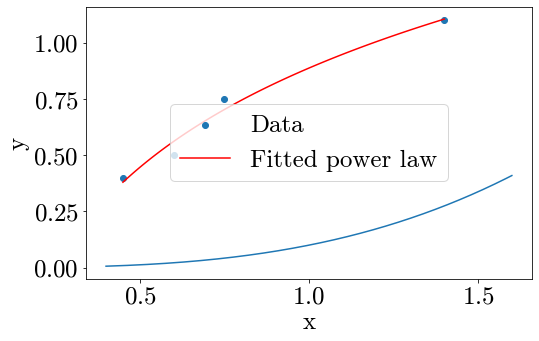

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law(x, a, b, c):
    return a * (x**b) + c

xdata = np.array([0.45, 0.6, 0.75, 1.4])
ydata = np.array([0.4, 0.5, 0.75, 1.1])

gmodel = Model(power_law)
result = gmodel.fit(ydata, x=xdata, a=0.8, b=3, c=0)
print(result.fit_report())

params, covariance = curve_fit(power_law, xdata, ydata)
a_fit, b_fit, c_fit = params
print(covariance)

print("Fitted parameters:")
print("a =", a_fit)
print("b =", b_fit)
print("c =", c_fit)

# Plot the original data points and the fitted curve
plt.figure(figsize=(8, 5))
plt.scatter(xdata, ydata, label="Data")
x_fit = np.linspace(min(xdata), max(xdata), 100)
plt.plot(x_fit, power_law(x_fit, a_fit, b_fit, c_fit), color="red", label="Fitted power law")
plt.plot(np.linspace(0.4, 1.6, 1000), power_law(np.linspace(0.4, 1.6, 1000), 0.1, 3, 0))
plt.xlabel("")
plt.ylabel("y")
plt.legend()
plt.show()
